# Notebook for Required Assignment Results



The entire notebook deals with the one-dimensional linear Gaussian state-space model.

# Basic Results — Linear Gaussian State-Space Model

## 1. Overview

This notebook documents an empirical study of a linear Gaussian state-space model (LG-SSM). The central goals are to understand how well we can recover latent states and unknown parameters from noisy observations, and to assess the consequences of fixing or misspecifying the observation coefficient $\alpha$.

**Model.** The latent state follows a stationary AR(1) process; observations are a scaled, noisy version of the state:

$$
x_t = \phi\, x_{t-1} + \varepsilon_t, \qquad \varepsilon_t \overset{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2),
$$

$$
y_t = \alpha\, x_t + \nu_t, \qquad \nu_t \overset{\text{iid}}{\sim} \mathcal{N}(0, \tau^2),
$$

with all noise terms mutually independent. The state is initialised at stationarity:

$$
x_0 \sim \mathcal{N}\!\left(0,\;\frac{\sigma^2}{1-\phi^2}\right).
$$

**True parameters used throughout:**

$$
\phi_0 = 0.9, \quad \alpha_0 = 1.5, \quad \sigma_0^2 = 1.0, \quad \tau_0^2 = 0.5, \quad T = 500.
$$

**Structure.** The notebook is divided into two sections. **Section I** uses a single simulated dataset to explore estimation methods and build intuition. **Section II** repeats the constrained estimation ($\alpha$ fixed) over $N = 200$ independent trials to support formal statistical inference.

**Methods covered.**

| § | Topic | Method |
|---|-------|--------|
| 2 | Data generation | Simulation from true parameters |
| 3 | Filtering under true params | Kalman filter (KF, exact) and particle filter (PF, $N=5000$) |
| 4 | Parameter estimation — free $\alpha$ | MLE via Kalman likelihood (L-BFGS-B, 3 restarts) |
| 5 | Parameter estimation — free $\alpha$ | Metropolis-Hastings (MH), flat prior on unconstrained space |
| 6 | Identifiability | Weak identification ridge: $\alpha^2\sigma^2 = \mathrm{const}$ |
| 7 | Constrained estimation | MLE and BlockMH with $\alpha$ fixed to 1.5 (true) and 1.0 (wrong) |
| 8 | Filtering under estimated params | KF with MLE and MH parameter estimates |
| 9 | RMSE analysis ($N=200$ trials) | Latent-state, observation, and one-step-ahead prediction RMSE |
| 10 | Hypothesis tests — parameters | One-sample $t$-tests: MLE and MH vs true values |
| 11 | $\sigma^2$ and $\tau^2$ scatter | Joint distribution of noise estimates; MLE vs MH covariance ellipses |
| 12 | Hypothesis tests — RMSE | Paired $t$-tests, latent space and signal space compared separately |

**Key identifiability observation.** The marginal observation variance
$\operatorname{Var}(y_t) = \alpha^2\sigma^2/(1-\phi^2) + \tau^2$
depends on $\alpha$ and $\sigma^2$ only through the product $\alpha^2\sigma^2$. When both are free, the likelihood is nearly flat along the hyperbolic ridge $\alpha^2\sigma^2 = \mathrm{const}$, making them individually weakly identified. Fixing $\alpha$ breaks the ridge and sharpens inference on the remaining parameters.

**Signal space vs latent space.** When $\alpha$ is misspecified as 1.0 instead of 1.5, the KF compensates by inflating $\hat\sigma^2$ by a factor of $(\alpha_0/\hat\alpha)^2 = 2.25$, so filtered means approximate $1.5\,x_t$ rather than $x_t$. Latent-space RMSE $(\,\mathrm{rmse}(\hat x_t, x_t)\,)$ then conflates scale error with filtering quality. Signal-space RMSE $(\,\mathrm{rmse}(\hat\alpha\,\hat x_t,\,\alpha_0 x_t)\,)$ provides a fair comparison across different $\alpha$ specifications, and is kept strictly separate from latent-space comparisons throughout Section II.


In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from models.linear_gaussian import SimpleLinearGaussianSSM, LinearGaussianSSM
from estimation.kalman_filter import KalmanFilter
from estimation.particle_filter import ParticleFilter
from estimation.mle_estimator import MLEEstimator
from estimation.metropolis_hastings import MetropolisHastings, BlockMetropolisHastings
from estimation.resampling_methods import SystematicResampling
from scipy.optimize import minimize

from utils import ess_trajectory, chain_ess, rmse

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
SEED = 42


# Section I. Basic Setup and Exploration of Estimation Methods

## 2. Synthetic data

We simulate a latent AR(1) state and noisy observations using the known true parameters. Since the latent state is simulated, we can evaluate filtering accuracy directly by comparing $\hat{x}_t$ with $x_t$.

In [ ]:
# true params
phi_true = 0.9
alpha_true = 1.5
sigma2_true = 1.0
tau2_true = 0.50

model = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true, sigma2=sigma2_true, tau2=tau2_true, seed=42)
print(model)

T = 500
states, observations, true_loglik = model.generate_data(T)

SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=1.0, tau2=0.5)


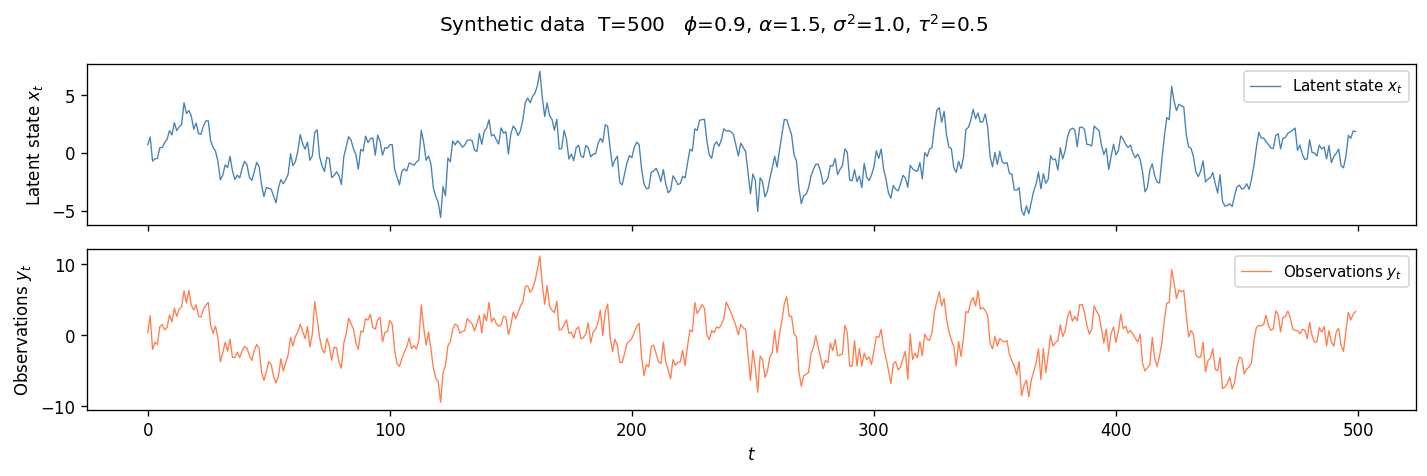

Conditional log-likelihood (true state path): -529.93


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(states.ravel(), lw=0.8, color='steelblue', label='Latent state $x_t$')
axes[1].plot(observations.ravel(), lw=0.8, color='coral',     label='Observations $y_t$')
for ax in axes:
    ax.legend(fontsize=9)
    ax.set_ylabel(ax.get_legend().get_texts()[0].get_text())
axes[1].set_xlabel('$t$')
fig.suptitle(f'Synthetic data  T={T}   '
             rf'$\phi$={phi_true}, $\alpha$={alpha_true}, '
             rf'$\sigma^2$={sigma2_true}, $\tau^2$={tau2_true}')
plt.tight_layout()
plt.show()
print(f"Conditional log-likelihood (true state path): {true_loglik:.2f}")


## 3. Filtering under true parameters: PF vs KF (vs true parameters)

Because the model is linear-Gaussian, the Kalman filter is the exact benchmark. The particle filter is a Monte Carlo approximation and should approach the Kalman result as the number of particles increases.

In [5]:
N_PARTICLES = 5000

# Particle filter
pf = ParticleFilter(model=model, N_particles=N_PARTICLES, data=observations,
                    resample_method=SystematicResampling(seed=SEED))
pf_states, _, _, _, pf_loglik = pf.run_filter()
pf_states = pf_states.ravel()

# Kalman filter (exact benchmark) — requires LinearGaussianSSM
kf_model = LinearGaussianSSM(
    a=np.array([[phi_true]]),
    c=np.array([[alpha_true]]),
    q=np.array([[sigma2_true]]),
    r=np.array([[tau2_true]]),
)
kf = KalmanFilter(kf_model, observations)
kf_means, kf_covs, kf_loglik = kf.run_filter()
kf_states = kf_means.ravel()
kf_stds   = np.sqrt(kf_covs.ravel())

print(f"Log-likelihood — KF (exact): {kf_loglik:.2f}")
print(f"Log-likelihood — PF (N={N_PARTICLES}): {pf_loglik:.2f}")
print(f"Log-likelihood — true state: {true_loglik:.2f}")
print(f"\nRMSE — KF: {rmse(states.ravel(), kf_states):.4f}")
print(f"RMSE — PF: {rmse(states.ravel(), pf_states):.4f}")


ParticleFilter.run_filter  16.525s
Log-likelihood — KF (exact): -1009.86
Log-likelihood — PF (N=5000): -1019.47
Log-likelihood — true state: -529.93

RMSE — KF: 0.3989
RMSE — PF: 0.4012


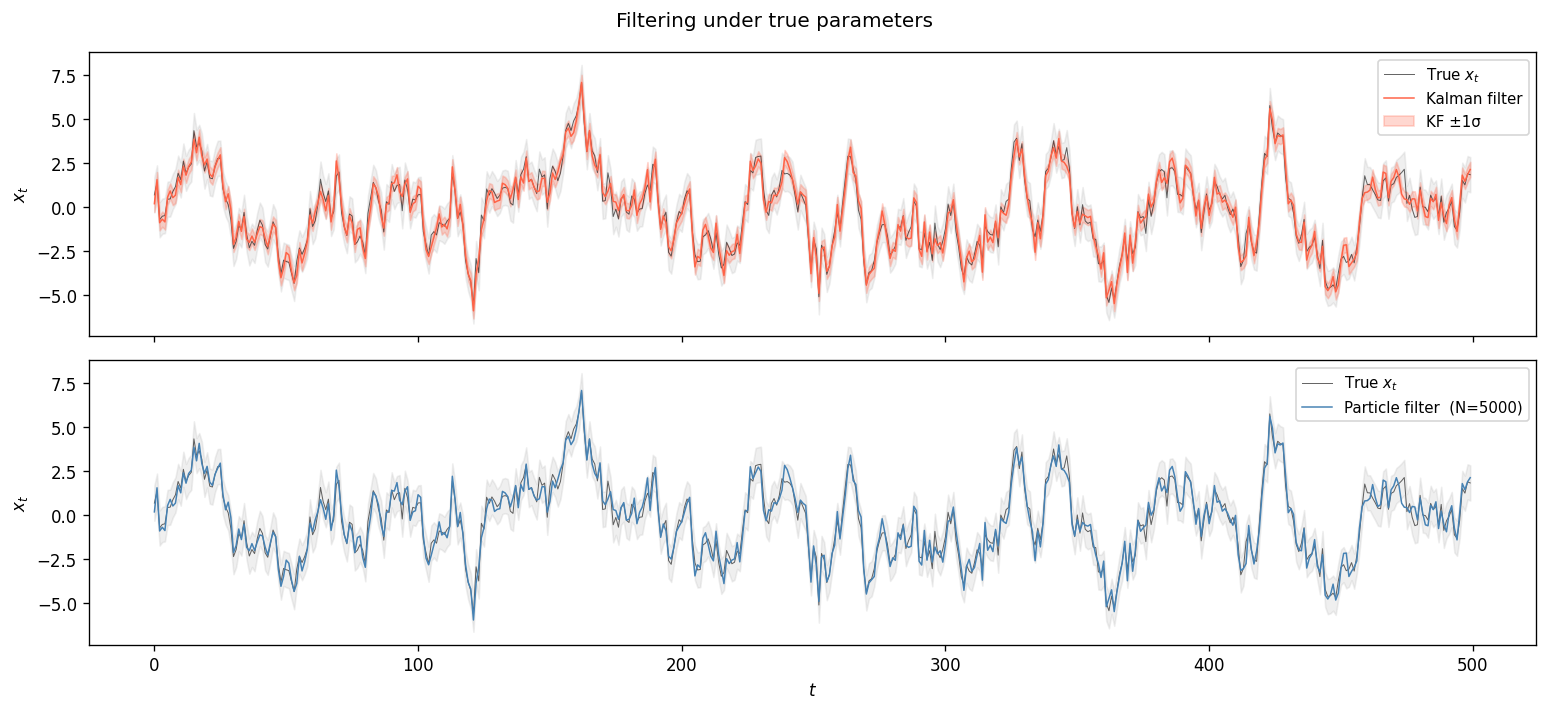

In [6]:
t_plot = np.arange(T)
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

for ax, est, label, color in [
    (axes[0], kf_states, 'Kalman filter', 'tomato'),
    (axes[1], pf_states, f'Particle filter  (N={N_PARTICLES})', 'steelblue'),
]:
    ax.fill_between(t_plot, states.ravel() - 1, states.ravel() + 1, alpha=0.12, color='grey')
    ax.plot(states.ravel(), lw=0.6, color='black', alpha=0.6, label='True $x_t$')
    ax.plot(est, lw=0.9, color=color, label=label)
    if color == 'tomato':                        # add KF ±1σ band
        ax.fill_between(t_plot, kf_states - kf_stds, kf_states + kf_stds,
                        alpha=0.25, color=color, label='KF ±1σ')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylabel('$x_t$')

axes[1].set_xlabel('$t$')
fig.suptitle('Filtering under true parameters')
plt.tight_layout()
plt.show()


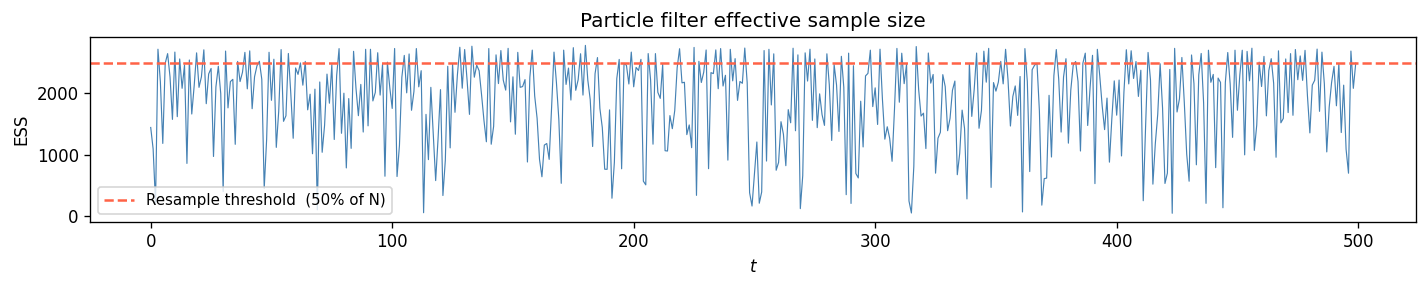

In [7]:
ess_traj = ess_trajectory(pf)
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.plot(ess_traj, lw=0.7, color='steelblue')
ax.axhline(pf.resample_threshold * N_PARTICLES, color='tomato', ls='--',
           label=f'Resample threshold  ({pf.resample_threshold*100:.0f}% of N)')
ax.set_xlabel('$t$'); ax.set_ylabel('ESS')
ax.set_title('Particle filter effective sample size')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 4. Parameter estimation: MLE using Kalman likelihood

(*Requires edit*) Add description of the MLE method implemented in `mle.py`; how std is calculated

In [8]:
mle_model = SimpleLinearGaussianSSM(phi=0.5, alpha=1.0, sigma2=0.5, tau2=0.5, seed=SEED)
theta0_mle = mle_model.unconstrain_params([0.5, 1.0, 0.5, 0.5])

mle = MLEEstimator(mle_model, observations, n_restarts=20, seed=SEED)
mle_result = mle.fit(theta0=theta0_mle)
mle.compute_std_errors()
print(mle_result.summary())

PARAM_NAMES  = ['phi', 'alpha', 'sigma2', 'tau2']
TRUE_VALS    = [phi_true, alpha_true, sigma2_true, tau2_true]
mle_est_vals = list(mle_result.constrained_params)
mle_se_vals  = list(mle_result.std_errors)


MLEEstimator.fit  0.953s
MLEResult  loglik=-1008.7724  converged  n_evals=110
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.878654      0.025056
  alpha                 2.221048             —
  sigma2                0.489569             —
  tau2                  0.539300      0.190048


We should see that the Std error for alpha and sigma2 are large or NaN, due to the non-identifiability of the model.

## 5. Parameter estimation: Metropolis-Hastings

Use prior on unconstrained parameters

MetropolisHastings.run  19.021s
Acceptance rate: 0.427


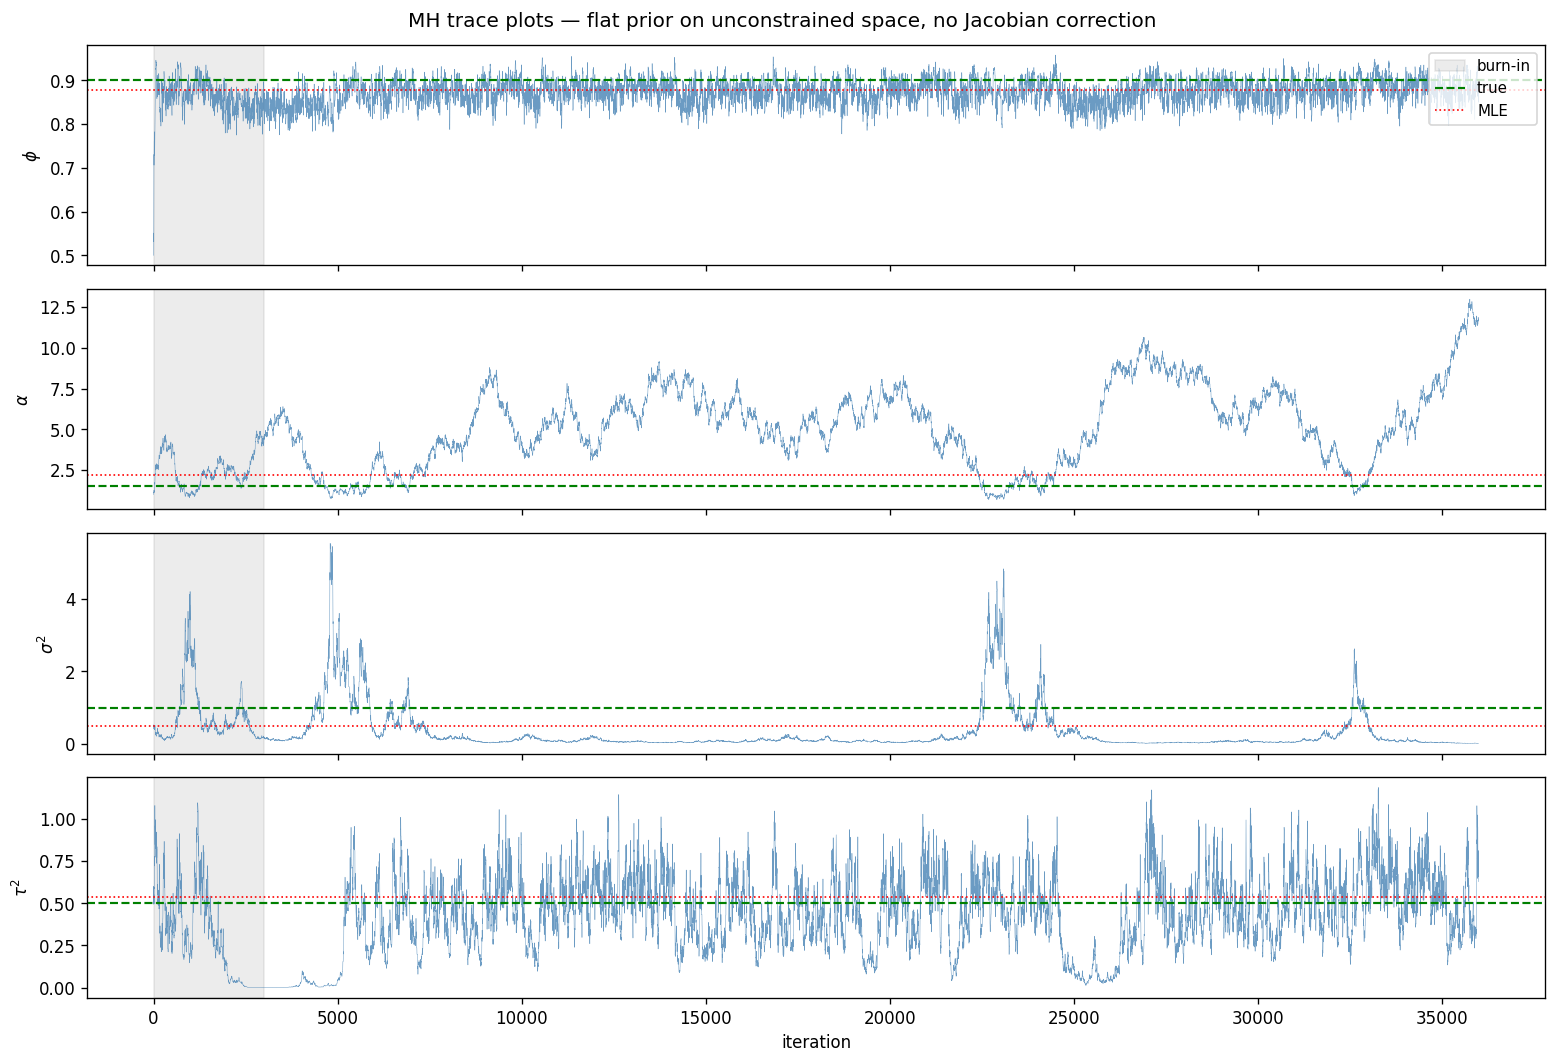

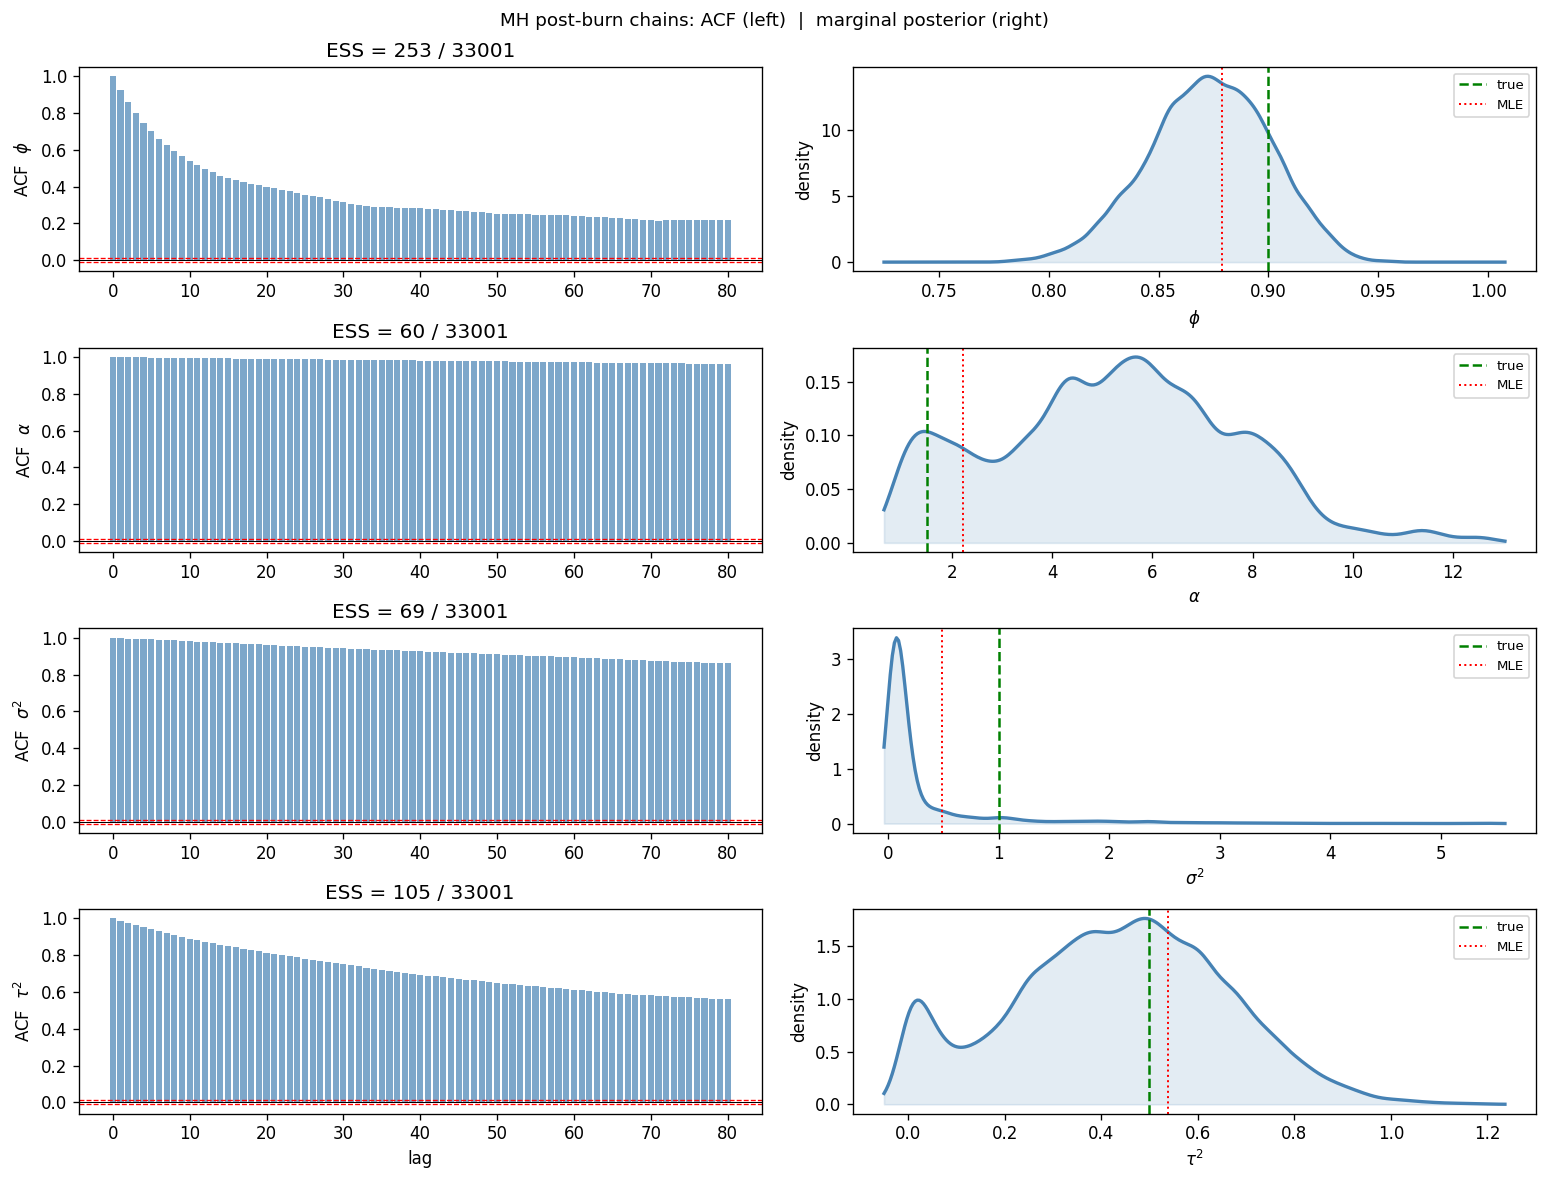


Param         Post. mean   Post. std      True       ESS
--------------------------------------------------------
phi               0.8730      0.0275    0.9000       253
alpha             5.2312      2.4027    1.5000        60
sigma2            0.3139      0.6149    1.0000        69
tau2              0.4298      0.2237    0.5000       105


In [9]:
N_MH  = 36_000
BURN  = 3_000

mh_model  = SimpleLinearGaussianSSM(phi=0.5, alpha=1.0, sigma2=0.5, tau2=0.5, seed=SEED)
theta0_mh = mh_model.unconstrain_params([0.5, 1.0, 0.5, 0.5])

mh = MetropolisHastings(
    model            = mh_model,
    data             = observations,
    n_iter           = N_MH,
    step_sizes       = np.array([0.08, 0.12, 0.12, 0.12]),
    theta0           = theta0_mh,
    prior_space      = 'unconstrained',   # flat prior on unconstrained space
    include_jacobian = False,             # no Jacobian correction
    seed             = SEED,
)
mh_chain, mh_loglik, _ = mh.run()
print(f"Acceptance rate: {mh.accept_rate:.3f}")

mh_con  = mh_model.constrain_chain(mh_chain[BURN:])   # post-burn constrained chain
mh_full = mh_model.constrain_chain(mh_chain)           # full chain for trace plots
LABELS  = [r'$\phi$', r'$\alpha$', r'$\sigma^2$', r'$\tau^2$']

# ── trace plots ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
for j, (ax, lbl) in enumerate(zip(axes, LABELS)):
    ax.plot(mh_full[:, j], lw=0.3, alpha=0.8, color='steelblue')
    ax.axvspan(0, BURN, color='grey', alpha=0.15, label='burn-in')
    ax.axhline(TRUE_VALS[j],    color='green', lw=1.3, ls='--', label='true')
    ax.axhline(mle_est_vals[j], color='red',   lw=1.0, ls=':',  label='MLE')
    ax.set_ylabel(lbl)
    if j == 0:
        ax.legend(fontsize=9, loc='upper right')
axes[-1].set_xlabel('iteration')
fig.suptitle('MH trace plots — flat prior on unconstrained space, no Jacobian correction')
plt.tight_layout(); plt.show()

# ── ACF and marginal densities ────────────────────────────────────────────────
from scipy.stats import gaussian_kde
fig, axes = plt.subplots(4, 2, figsize=(13, 10))
fig.suptitle('MH post-burn chains: ACF (left)  |  marginal posterior (right)', fontsize=11)

max_lag = 80
ess_vals = []
for j, (lbl, pname) in enumerate(zip(LABELS, PARAM_NAMES)):
    samples = mh_con[:, j]
    ess_j   = chain_ess(samples)
    ess_vals.append(ess_j)

    # ACF
    ax_acf = axes[j, 0]
    xc = samples - samples.mean()
    var = xc.var()
    ac = [np.mean(xc[k:] * xc[:len(xc)-k]) / var for k in range(max_lag + 1)]
    ax_acf.bar(range(max_lag + 1), ac, width=0.8, color='steelblue', alpha=0.7)
    ax_acf.axhline(0, color='black', lw=0.6)
    ci = 1.96 / np.sqrt(len(samples))
    ax_acf.axhline( ci, color='red', lw=0.8, ls='--')
    ax_acf.axhline(-ci, color='red', lw=0.8, ls='--')
    ax_acf.set_ylabel(f'ACF  {lbl}')
    ax_acf.set_title(f'ESS = {ess_j:.0f} / {len(samples)}')

    # KDE
    ax_kde = axes[j, 1]
    kde  = gaussian_kde(samples, bw_method='scott')
    grid = np.linspace(samples.min() - 0.05, samples.max() + 0.05, 300)
    ax_kde.plot(grid, kde(grid), color='steelblue', lw=2)
    ax_kde.fill_between(grid, kde(grid), alpha=0.15, color='steelblue')
    ax_kde.axvline(TRUE_VALS[j],    color='green', lw=1.5, ls='--', label='true')
    ax_kde.axvline(mle_est_vals[j], color='red',   lw=1.2, ls=':',  label='MLE')
    ax_kde.set_xlabel(lbl); ax_kde.set_ylabel('density')
    ax_kde.legend(fontsize=8)

axes[-1, 0].set_xlabel('lag')
plt.tight_layout(); plt.show()

print(f"\n{'Param':<10}  {'Post. mean':>12}  {'Post. std':>10}  {'True':>8}  {'ESS':>8}")
print('-' * 56)
for j, p in enumerate(PARAM_NAMES):
    print(f"{p:<10}  {mh_con[:,j].mean():>12.4f}  {mh_con[:,j].std():>10.4f}  "
          f"{TRUE_VALS[j]:>8.4f}  {ess_vals[j]:>8.0f}")


We should see large correlation and low effective sample size for alpha and sigma2, again due to weak identifiability. The chains for alpha and sigma2 should also be moving in opposite directions.

## 6. Weak identifiability ridge

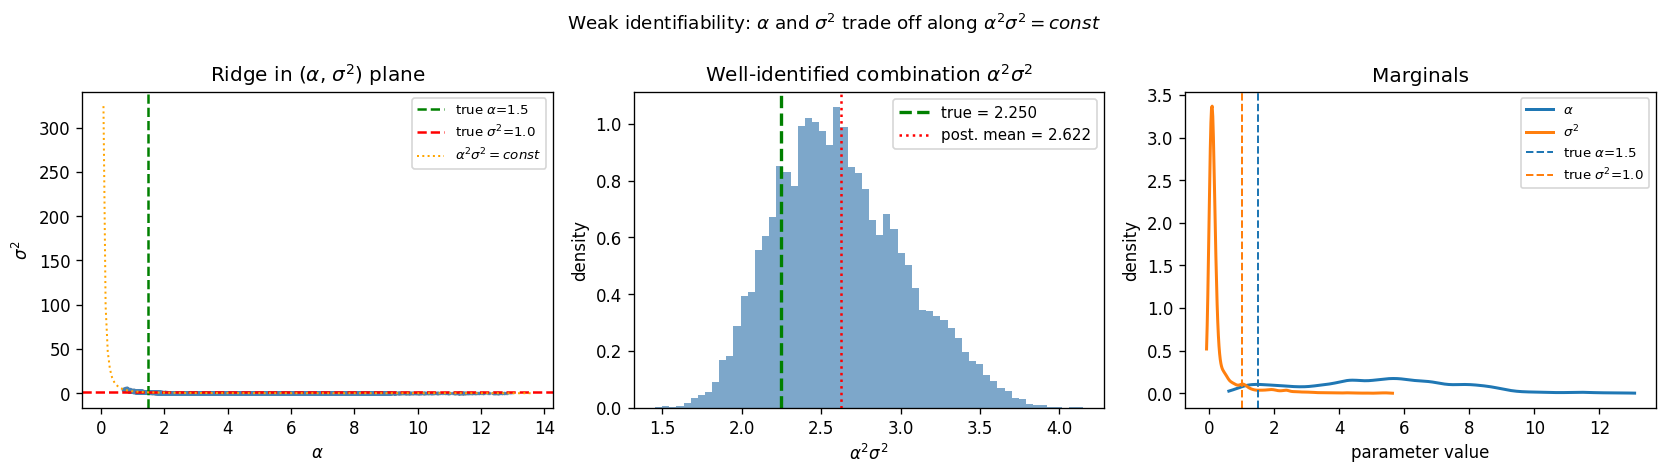


Posterior std — alpha : 2.4027
Posterior std — sigma2: 0.6149
Posterior std — alpha^2*sigma2: 0.4036  (CV = 0.1539)


In [10]:
# In this model the marginal covariance of y_t depends on alpha and sigma2
# only through the product  alpha^2 * sigma2.  When both are free the
# likelihood is nearly constant along the ridge  alpha^2 * sigma2 = const,
# making the individual parameters weakly identified.

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(r'Weak identifiability: $\alpha$ and $\sigma^2$ trade off along $\alpha^2\sigma^2 = const$', fontsize=11)

# 1. Scatter alpha vs sigma2
ax = axes[0]
ax.scatter(mh_con[:, 1], mh_con[:, 2], s=1, alpha=0.2, color='steelblue', rasterized=True)
ax.axvline(alpha_true,  color='green', lw=1.5, ls='--', label=rf'true $\alpha$={alpha_true}')
ax.axhline(sigma2_true, color='red',   lw=1.5, ls='--', label=rf'true $\sigma^2$={sigma2_true}')
xs = np.linspace(*ax.get_xlim(), 200)
ridge_sigma2 = (alpha_true**2 * sigma2_true) / xs**2
ax.plot(xs, ridge_sigma2, color='orange', lw=1.2, ls=':', label=r'$\alpha^2\sigma^2=const$')
ax.set_xlabel(r'$\alpha$'); ax.set_ylabel(r'$\sigma^2$')
ax.set_title(r'Ridge in ($\alpha$, $\sigma^2$) plane')
ax.legend(fontsize=8)

# 2. Well-identified combination alpha^2 * sigma2
ax = axes[1]
signal = mh_con[:, 1]**2 * mh_con[:, 2]
true_signal = alpha_true**2 * sigma2_true
ax.hist(signal, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='none')
ax.axvline(true_signal, color='green', lw=2, ls='--',
           label=rf'true = {true_signal:.3f}')
ax.axvline(signal.mean(), color='red', lw=1.5, ls=':',
           label=rf'post. mean = {signal.mean():.3f}')
ax.set_xlabel(r'$\alpha^2 \sigma^2$'); ax.set_ylabel('density')
ax.set_title(r'Well-identified combination $\alpha^2\sigma^2$')
ax.legend(fontsize=9)

# 3. Individual alpha and sigma2 marginals (wide)
ax = axes[2]
from scipy.stats import gaussian_kde
for j, (col, lbl, tv) in enumerate([(1, r'$\alpha$', alpha_true), (2, r'$\sigma^2$', sigma2_true)]):
    samples = mh_con[:, j + (1 if j == 0 else 1)]  # reuse mh_con
    kde  = gaussian_kde(mh_con[:, j + 1], bw_method='scott')
    grid = np.linspace(mh_con[:, j+1].min()-0.1, mh_con[:,j+1].max()+0.1, 300)
    ax.plot(grid, kde(grid), label=lbl, lw=1.8)
ax.axvline(alpha_true,  color='C0', lw=1.2, ls='--', label=rf'true $\alpha$={alpha_true}')
ax.axvline(sigma2_true, color='C1', lw=1.2, ls='--', label=rf'true $\sigma^2$={sigma2_true}')
ax.set_xlabel('parameter value'); ax.set_ylabel('density')
ax.set_title('Marginals')
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"\nPosterior std — alpha : {mh_con[:,1].std():.4f}")
print(f"Posterior std — sigma2: {mh_con[:,2].std():.4f}")
print(f"Posterior std — alpha^2*sigma2: {signal.std():.4f}  "
      f"(CV = {signal.std()/signal.mean():.4f})")


For alpha and ssigma2, we should see one marginal is wide while the other is small due to the inverse relationship.

## 7. Redo parameter estimation with $\alpha$ fixed

### 7a. Fix $\alpha$=1.5

MLE (alpha fixed = 1.5):
  phi      = 0.8787   (true: 0.9000)
  alpha    = 1.5000   (true: 1.5000)
  sigma2   = 1.0734   (true: 1.0000)
  tau2     = 0.5393   (true: 0.5000)
  loglik = -1008.77
BlockMetropolisHastings.run  19.088s

MH (alpha fixed = 1.5) acceptance rate: 0.469


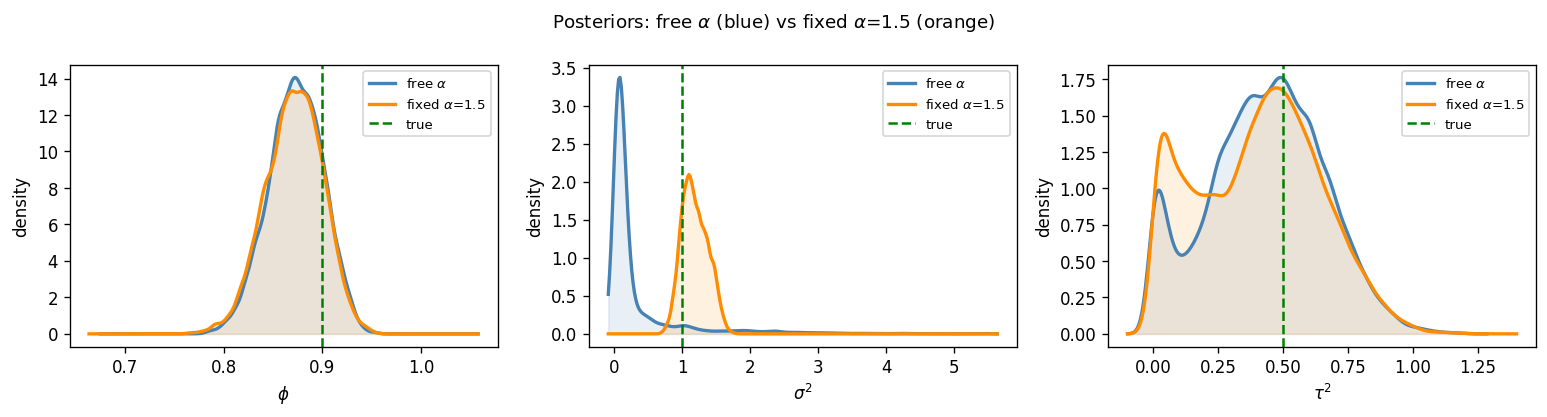


Param         ESS free   ESS fixed a=1.5
----------------------------------------
phi                253               216
sigma2              69               117
tau2               105               100


In [11]:
ALPHA_FIX15 = 1.5

# MLE with alpha fixed to 1.5
def mle_fixed_alpha(model, data, alpha_fixed, seed):
    """MLE over (phi, sigma2, tau2) with alpha fixed."""
    rng = np.random.default_rng(seed)
    best = {'loglik': -np.inf}
    for _ in range(3):
        u0 = np.array([np.arctanh(0.5 + 0.4*rng.uniform(-1,1)),
                       np.log(0.5 + rng.uniform(0, 0.5)),
                       np.log(0.5 + rng.uniform(0, 0.5))])
        def neg_ll(p):
            try:
                model.update_params([np.tanh(p[0]), alpha_fixed, np.exp(p[1]), np.exp(p[2])])
                return -float(model.log_likelihood(data))
            except Exception:
                return np.inf
        res = minimize(neg_ll, u0, method='L-BFGS-B')
        if -res.fun > best['loglik']:
            best = {'phi': np.tanh(res.x[0]), 'alpha': alpha_fixed,
                    'sigma2': np.exp(res.x[1]), 'tau2': np.exp(res.x[2]),
                    'loglik': -res.fun, 'success': res.success}
    return best

mle_fix15_model = SimpleLinearGaussianSSM(phi=0.5, alpha=ALPHA_FIX15, sigma2=0.5, tau2=0.5, seed=SEED)
mle_fix15 = mle_fixed_alpha(mle_fix15_model, observations, ALPHA_FIX15, SEED)

print(f"MLE (alpha fixed = {ALPHA_FIX15}):")
for p in PARAM_NAMES:
    print(f"  {p:<8} = {mle_fix15[p]:.4f}   (true: {dict(zip(PARAM_NAMES,TRUE_VALS))[p]:.4f})")
print(f"  loglik = {mle_fix15['loglik']:.2f}")

# MH with alpha fixed to 1.5 — use BlockMH, only blocks [phi, sigma2, tau2]
mh_fix15_model = SimpleLinearGaussianSSM(phi=0.5, alpha=ALPHA_FIX15, sigma2=0.5, tau2=0.5, seed=SEED)
theta0_fix15   = mh_fix15_model.unconstrain_params([0.5, ALPHA_FIX15, 0.5, 0.5])

mh_fix15 = BlockMetropolisHastings(
    model            = mh_fix15_model,
    data             = observations,
    n_iter           = N_MH,
    step_sizes       = np.array([0.08, 0.0, 0.12, 0.12]),
    theta0           = theta0_fix15,
    prior_space      = 'unconstrained',
    include_jacobian = False,
    blocks           = [[0, 2, 3]],   # phi=0, sigma2=2, tau2=3; alpha=1 fixed
    seed             = SEED,
)
mh_fix15_chain, _, _ = mh_fix15.run()
print(f"\nMH (alpha fixed = {ALPHA_FIX15}) acceptance rate: {mh_fix15.accept_rate:.3f}")

mh_fix15_con = mh_fix15_model.constrain_chain(mh_fix15_chain[BURN:])

# Comparison plot: free vs fixed alpha=1.5
FREE_IDXS = [0, 2, 3]  # phi, sigma2, tau2 (same indices in both chains)
FIX_LABELS = [r'$\phi$', r'$\sigma^2$', r'$\tau^2$']
FIX_TRUE   = [phi_true, sigma2_true, tau2_true]

from scipy.stats import gaussian_kde
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
fig.suptitle(rf'Posteriors: free $\alpha$ (blue) vs fixed $\alpha$=1.5 (orange)', fontsize=11)
for ax, idx, lbl, tv in zip(axes, FREE_IDXS, FIX_LABELS, FIX_TRUE):
    for samples, color, name in [
        (mh_con[:, idx],      'steelblue',  rf'free $\alpha$'),
        (mh_fix15_con[:, idx],'darkorange', rf'fixed $\alpha$={ALPHA_FIX15}'),
    ]:
        kde  = gaussian_kde(samples, bw_method='scott')
        grid = np.linspace(min(samples.min(), mh_con[:,idx].min()) - 0.1,
                           max(samples.max(), mh_con[:,idx].max()) + 0.1, 300)
        ax.plot(grid, kde(grid), color=color, lw=2, label=name)
        ax.fill_between(grid, kde(grid), alpha=0.12, color=color)
    ax.axvline(tv, color='green', lw=1.5, ls='--', label='true')
    ax.set_xlabel(lbl); ax.set_ylabel('density')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ESS comparison
print(f"\n{'Param':<10}  {'ESS free':>10}  {'ESS fixed a=1.5':>16}")
print('-' * 40)
for idx, p in zip(FREE_IDXS, ['phi', 'sigma2', 'tau2']):
    e_free  = chain_ess(mh_con[:, idx])
    e_fixed = chain_ess(mh_fix15_con[:, idx])
    print(f"{p:<10}  {e_free:>10.0f}  {e_fixed:>16.0f}")


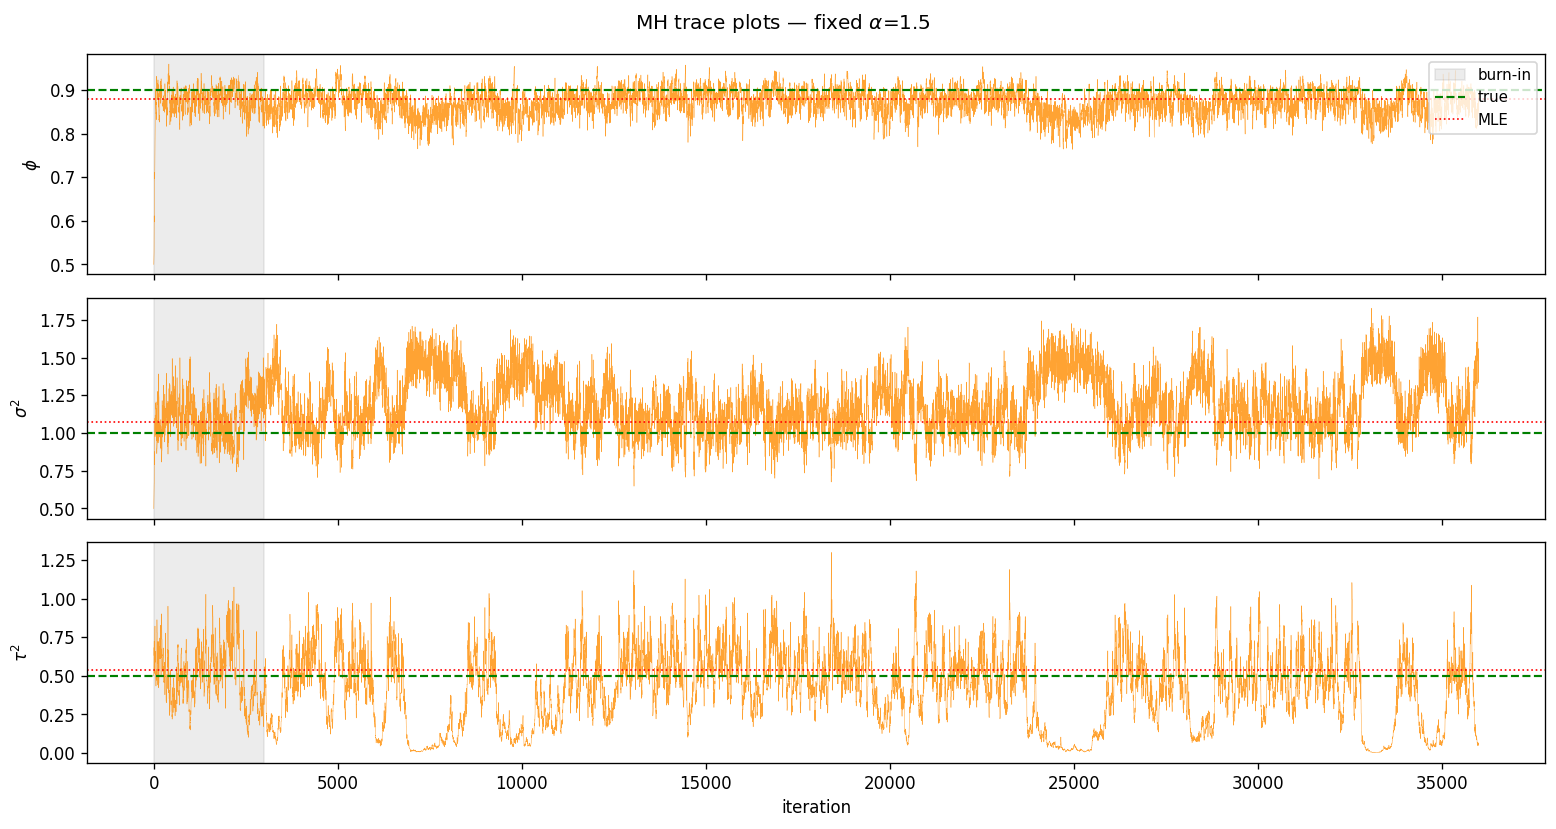

In [12]:

mh_fix15_full_con = mh_fix15_model.constrain_chain(mh_fix15_chain)
_fix15_mle_ref = [mle_fix15['phi'], mle_fix15['sigma2'], mle_fix15['tau2']]

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
for ax, lbl, idx, tv, mv in zip(
    axes,
    [r'$\phi$', r'$\sigma^2$', r'$\tau^2$'],
    [0, 2, 3],
    [phi_true, sigma2_true, tau2_true],
    _fix15_mle_ref,
):
    ax.plot(mh_fix15_full_con[:, idx], lw=0.3, alpha=0.8, color='darkorange')
    ax.axvspan(0, BURN, color='grey', alpha=0.15, label='burn-in')
    ax.axhline(tv, color='green', lw=1.3, ls='--', label='true')
    ax.axhline(mv, color='red',   lw=1.0, ls=':',  label='MLE')
    ax.set_ylabel(lbl)
    if ax is axes[0]:
        ax.legend(fontsize=9, loc='upper right')
axes[-1].set_xlabel('iteration')
fig.suptitle(rf'MH trace plots — fixed $\alpha$={ALPHA_FIX15}')
plt.tight_layout(); plt.show()


### 7b. Fix $\alpha$=1.0

MLE (alpha fixed = 1.0):
  phi      = 0.8787   (true: 0.9000)
  alpha    = 1.0000   (true: 1.5000)
  sigma2   = 2.4151   (true: 1.0000)
  tau2     = 0.5393   (true: 0.5000)
  loglik = -1008.77
  (MLE free alpha loglik = -1008.77)
BlockMetropolisHastings.run  18.872s

MH (alpha fixed = 1.0) acceptance rate: 0.475


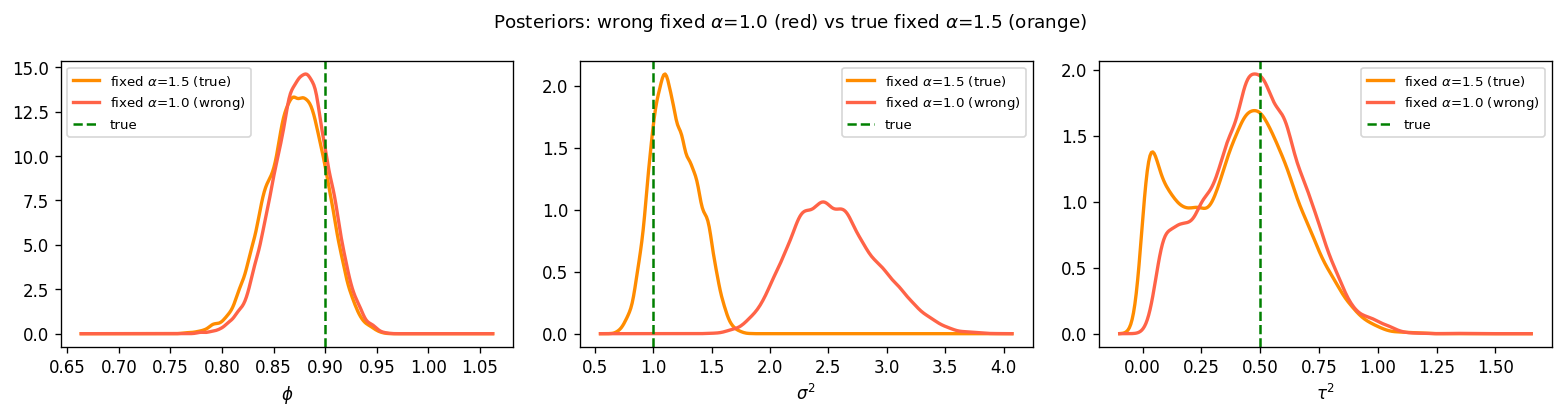


True alpha^2*sigma2       = 2.250
Est  alpha^2*sigma2 (a=1.5): 2.415
Est  alpha^2*sigma2 (a=1.0): 2.415
Expected sigma2 if a=1.0:    2.250  (ratio = (1.5/1.0)^2 = 2.25x)


In [13]:
ALPHA_FIX10 = 1.0

mle_fix10_model = SimpleLinearGaussianSSM(phi=0.5, alpha=ALPHA_FIX10, sigma2=0.5, tau2=0.5, seed=SEED)
mle_fix10 = mle_fixed_alpha(mle_fix10_model, observations, ALPHA_FIX10, SEED)

print(f"MLE (alpha fixed = {ALPHA_FIX10}):")
for p in PARAM_NAMES:
    print(f"  {p:<8} = {mle_fix10[p]:.4f}   (true: {dict(zip(PARAM_NAMES,TRUE_VALS))[p]:.4f})")
print(f"  loglik = {mle_fix10['loglik']:.2f}")
print(f"  (MLE free alpha loglik = {mle_result.loglik:.2f})")

# MH with alpha fixed to 1.0
mh_fix10_model = SimpleLinearGaussianSSM(phi=0.5, alpha=ALPHA_FIX10, sigma2=0.5, tau2=0.5, seed=SEED)
theta0_fix10   = mh_fix10_model.unconstrain_params([0.5, ALPHA_FIX10, 0.5, 0.5])

mh_fix10 = BlockMetropolisHastings(
    model            = mh_fix10_model,
    data             = observations,
    n_iter           = N_MH,
    step_sizes       = np.array([0.08, 0.0, 0.12, 0.12]),
    theta0           = theta0_fix10,
    prior_space      = 'unconstrained',
    include_jacobian = False,
    blocks           = [[0, 2, 3]],
    seed             = SEED,
)
mh_fix10_chain, _, _ = mh_fix10.run()
print(f"\nMH (alpha fixed = {ALPHA_FIX10}) acceptance rate: {mh_fix10.accept_rate:.3f}")

mh_fix10_con = mh_fix10_model.constrain_chain(mh_fix10_chain[BURN:])

# Show how wrong alpha forces sigma2 to compensate: alpha^2*sigma2 must stay ≈ const
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
fig.suptitle(rf'Posteriors: wrong fixed $\alpha$=1.0 (red) vs true fixed $\alpha$=1.5 (orange)', fontsize=11)
for ax, idx, lbl, tv in zip(axes, FREE_IDXS, FIX_LABELS, FIX_TRUE):
    for samples, color, name in [
        (mh_fix15_con[:, idx], 'darkorange', rf'fixed $\alpha$=1.5 (true)'),
        (mh_fix10_con[:, idx], 'tomato',     rf'fixed $\alpha$=1.0 (wrong)'),
    ]:
        kde  = gaussian_kde(samples, bw_method='scott')
        grid = np.linspace(min(mh_fix10_con[:,idx].min(), mh_fix15_con[:,idx].min()) - 0.1,
                           max(mh_fix10_con[:,idx].max(), mh_fix15_con[:,idx].max()) + 0.1, 300)
        ax.plot(grid, kde(grid), color=color, lw=2, label=name)
    ax.axvline(tv, color='green', lw=1.5, ls='--', label='true')
    ax.set_xlabel(lbl)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Expected sigma2 compensation: with wrong alpha=1.0, sigma2 should inflate ~(1.5/1.0)^2 = 2.25x
print(f"\nTrue alpha^2*sigma2       = {alpha_true**2 * sigma2_true:.3f}")
print(f"Est  alpha^2*sigma2 (a=1.5): {ALPHA_FIX15**2 * mle_fix15['sigma2']:.3f}")
print(f"Est  alpha^2*sigma2 (a=1.0): {ALPHA_FIX10**2 * mle_fix10['sigma2']:.3f}")
print(f"Expected sigma2 if a=1.0:    {(alpha_true/ALPHA_FIX10)**2 * sigma2_true:.3f}  "
      f"(ratio = ({alpha_true}/{ALPHA_FIX10})^2 = {(alpha_true/ALPHA_FIX10)**2:.2f}x)")


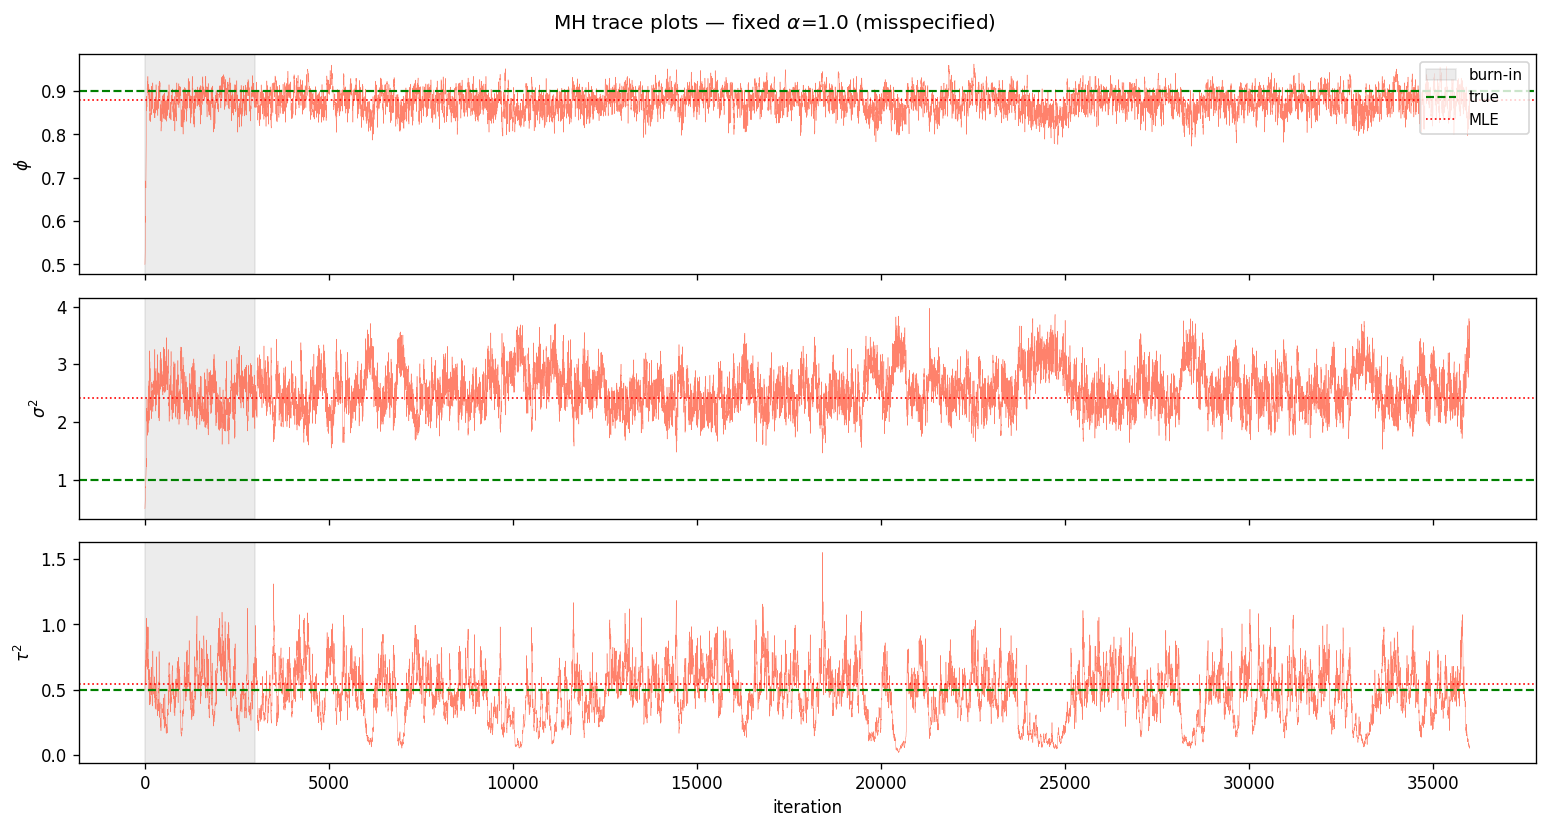

In [14]:

mh_fix10_full_con = mh_fix10_model.constrain_chain(mh_fix10_chain)
_fix10_mle_ref = [mle_fix10['phi'], mle_fix10['sigma2'], mle_fix10['tau2']]

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
for ax, lbl, idx, tv, mv in zip(
    axes,
    [r'$\phi$', r'$\sigma^2$', r'$\tau^2$'],
    [0, 2, 3],
    [phi_true, sigma2_true, tau2_true],
    _fix10_mle_ref,
):
    ax.plot(mh_fix10_full_con[:, idx], lw=0.3, alpha=0.8, color='tomato')
    ax.axvspan(0, BURN, color='grey', alpha=0.15, label='burn-in')
    ax.axhline(tv, color='green', lw=1.3, ls='--', label='true')
    ax.axhline(mv, color='red',   lw=1.0, ls=':',  label='MLE')
    ax.set_ylabel(lbl)
    if ax is axes[0]:
        ax.legend(fontsize=9, loc='upper right')
axes[-1].set_xlabel('iteration')
fig.suptitle(rf'MH trace plots — fixed $\alpha$={ALPHA_FIX10} (misspecified)')
plt.tight_layout(); plt.show()


# Section II. Statistical Analysis

To do statistical inference and hypothesis testing properly, we do multiple independent runs of the model and parameter estimation (under different seeds).

In [29]:
import os
import pandas as pd

RESULTS_FILE = '../results/trial_results.csv'
N_TRIALS = 200

# ── per-trial RMSE helpers ────────────────────────────────────────────────────

def _kf_latent_rmse(phi, alpha, sigma2, tau2, obs, latent):
    """rmse(x_t, x̂_{t|t})  — latent state RMSE."""
    m = LinearGaussianSSM(
        a=np.array([[phi]]), c=np.array([[alpha]]),
        q=np.array([[sigma2]]), r=np.array([[tau2]]),
    )
    means, _, _ = KalmanFilter(m, obs).run_filter()
    return rmse(latent.ravel(), means.ravel())

def _kf_obs_rmse(phi, alpha, sigma2, tau2, obs, latent):
    """rmse(y_t, α*x̂_{t|t})  — filtered signal vs observations."""
    m = LinearGaussianSSM(
        a=np.array([[phi]]), c=np.array([[alpha]]),
        q=np.array([[sigma2]]), r=np.array([[tau2]]),
    )
    means, _, _ = KalmanFilter(m, obs).run_filter()
    return rmse(obs.ravel(), alpha * means.ravel())

def _kf_pred_rmse(phi, alpha, sigma2, tau2, obs, latent):
    """rmse(y_t, α*x̂_{t|t-1})  — one-step-ahead prediction vs observations (t=1..T-1)."""
    m = LinearGaussianSSM(
        a=np.array([[phi]]), c=np.array([[alpha]]),
        q=np.array([[sigma2]]), r=np.array([[tau2]]),
    )
    kf = KalmanFilter(m, obs)
    kf.run_filter()
    pred = kf.predicted_means.ravel()
    return rmse(obs.ravel()[1:], alpha * pred[1:])

def _kf_signal_rmse(phi, alpha_est, sigma2, tau2, obs, latent):
    """rmse(α_true*x_t, α_est*x̂_{t|t})  — signal-space RMSE for misspecified alpha."""
    m = LinearGaussianSSM(
        a=np.array([[phi]]), c=np.array([[alpha_est]]),
        q=np.array([[sigma2]]), r=np.array([[tau2]]),
    )
    means, _, _ = KalmanFilter(m, obs).run_filter()
    return rmse(alpha_true * latent.ravel(), alpha_est * means.ravel())

# ── single-trial function ─────────────────────────────────────────────────────

def run_single_trial(r):
    seed_r = 10_000 + r

    true_model_r = SimpleLinearGaussianSSM(
        phi=phi_true, alpha=alpha_true, sigma2=sigma2_true, tau2=tau2_true,
        seed=seed_r + 100,
    )
    latent_r, obs_r, _ = true_model_r.generate_data(T)

    # MLE — alpha fixed to 1.5
    mle_fix15_model_r = SimpleLinearGaussianSSM(phi=0.5, alpha=1.5, sigma2=0.5, tau2=0.5, seed=seed_r)
    mle_fix15_r = mle_fixed_alpha(mle_fix15_model_r, obs_r, 1.5, seed_r + 100)

    # MH — alpha fixed to 1.5
    mh_fix15_model_r = SimpleLinearGaussianSSM(phi=0.5, alpha=1.5, sigma2=0.5, tau2=0.5, seed=seed_r)
    mh_fix15_r = BlockMetropolisHastings(
        model=mh_fix15_model_r, data=obs_r, n_iter=N_MH,
        step_sizes=np.array([0.08, 0.0, 0.12, 0.12]),
        theta0=mh_fix15_model_r.unconstrain_params([0.5, 1.5, 0.5, 0.5]),
        prior_space='unconstrained', include_jacobian=False,
        blocks=[[0, 2, 3]], seed=seed_r,
    )
    mh_fix15_chain_r, _, _ = mh_fix15_r.run()
    mh_fix15_con_r = mh_fix15_model_r.constrain_chain(mh_fix15_chain_r[BURN:])
    mh_fix15_phi_r    = mh_fix15_con_r[:, 0].mean()
    mh_fix15_sigma2_r = mh_fix15_con_r[:, 2].mean()
    mh_fix15_tau2_r   = mh_fix15_con_r[:, 3].mean()

    # MLE — alpha fixed to 1.0
    mle_fix10_model_r = SimpleLinearGaussianSSM(phi=0.5, alpha=1.0, sigma2=0.5, tau2=0.5, seed=seed_r)
    mle_fix10_r = mle_fixed_alpha(mle_fix10_model_r, obs_r, 1.0, seed_r + 300)

    # MH — alpha fixed to 1.0
    mh_fix10_model_r = SimpleLinearGaussianSSM(phi=0.5, alpha=1.0, sigma2=0.5, tau2=0.5, seed=seed_r)
    mh_fix10_r = BlockMetropolisHastings(
        model=mh_fix10_model_r, data=obs_r, n_iter=N_MH,
        step_sizes=np.array([0.08, 0.0, 0.12, 0.12]),
        theta0=mh_fix10_model_r.unconstrain_params([0.5, 1.0, 0.5, 0.5]),
        prior_space='unconstrained', include_jacobian=False,
        blocks=[[0, 2, 3]], seed=seed_r,
    )
    mh_fix10_chain_r, _, _ = mh_fix10_r.run()
    mh_fix10_con_r = mh_fix10_model_r.constrain_chain(mh_fix10_chain_r[BURN:])
    mh_fix10_phi_r    = mh_fix10_con_r[:, 0].mean()
    mh_fix10_sigma2_r = mh_fix10_con_r[:, 2].mean()
    mh_fix10_tau2_r   = mh_fix10_con_r[:, 3].mean()

    return {
        # parameter estimates
        'mle_fix15_phi':    mle_fix15_r['phi'],
        'mle_fix15_sigma2': mle_fix15_r['sigma2'],
        'mle_fix15_tau2':   mle_fix15_r['tau2'],
        'mle_fix15_loglik': mle_fix15_r['loglik'],
        'mh_fix15_phi':     mh_fix15_phi_r,
        'mh_fix15_sigma2':  mh_fix15_sigma2_r,
        'mh_fix15_tau2':    mh_fix15_tau2_r,

        'mle_fix10_phi':    mle_fix10_r['phi'],
        'mle_fix10_sigma2': mle_fix10_r['sigma2'],
        'mle_fix10_tau2':   mle_fix10_r['tau2'],
        'mle_fix10_loglik': mle_fix10_r['loglik'],
        'mh_fix10_phi':     mh_fix10_phi_r,
        'mh_fix10_sigma2':  mh_fix10_sigma2_r,
        'mh_fix10_tau2':    mh_fix10_tau2_r,

        # latent state RMSE  rmse(x̂_{t|t}, x_t)
        'rmse_kf_true':   _kf_latent_rmse(phi_true,             alpha_true, sigma2_true,             tau2_true,             obs_r, latent_r),
        'rmse_mle_fix15': _kf_latent_rmse(mle_fix15_r['phi'],   1.5,        mle_fix15_r['sigma2'],   mle_fix15_r['tau2'],   obs_r, latent_r),
        'rmse_mh_fix15':  _kf_latent_rmse(mh_fix15_phi_r,       1.5,        mh_fix15_sigma2_r,       mh_fix15_tau2_r,       obs_r, latent_r),
        'rmse_mle_fix10': _kf_latent_rmse(mle_fix10_r['phi'],   1.0,        mle_fix10_r['sigma2'],   mle_fix10_r['tau2'],   obs_r, latent_r),
        'rmse_mh_fix10':  _kf_latent_rmse(mh_fix10_phi_r,       1.0,        mh_fix10_sigma2_r,       mh_fix10_tau2_r,       obs_r, latent_r),

        # observation RMSE  rmse(α*x̂_{t|t}, y_t)
        'rmse_obs_kf_true':   _kf_obs_rmse(phi_true,             alpha_true, sigma2_true,             tau2_true,             obs_r, latent_r),
        'rmse_obs_mle_fix15': _kf_obs_rmse(mle_fix15_r['phi'],   1.5,        mle_fix15_r['sigma2'],   mle_fix15_r['tau2'],   obs_r, latent_r),
        'rmse_obs_mh_fix15':  _kf_obs_rmse(mh_fix15_phi_r,       1.5,        mh_fix15_sigma2_r,       mh_fix15_tau2_r,       obs_r, latent_r),
        'rmse_obs_mle_fix10': _kf_obs_rmse(mle_fix10_r['phi'],   1.0,        mle_fix10_r['sigma2'],   mle_fix10_r['tau2'],   obs_r, latent_r),
        'rmse_obs_mh_fix10':  _kf_obs_rmse(mh_fix10_phi_r,       1.0,        mh_fix10_sigma2_r,       mh_fix10_tau2_r,       obs_r, latent_r),

        # prediction RMSE  rmse(α*x̂_{t|t-1}, y_t)  for t=1..T-1
        'rmse_pred_kf_true':   _kf_pred_rmse(phi_true,             alpha_true, sigma2_true,             tau2_true,             obs_r, latent_r),
        'rmse_pred_mle_fix15': _kf_pred_rmse(mle_fix15_r['phi'],   1.5,        mle_fix15_r['sigma2'],   mle_fix15_r['tau2'],   obs_r, latent_r),
        'rmse_pred_mh_fix15':  _kf_pred_rmse(mh_fix15_phi_r,       1.5,        mh_fix15_sigma2_r,       mh_fix15_tau2_r,       obs_r, latent_r),
        'rmse_pred_mle_fix10': _kf_pred_rmse(mle_fix10_r['phi'],   1.0,        mle_fix10_r['sigma2'],   mle_fix10_r['tau2'],   obs_r, latent_r),
        'rmse_pred_mh_fix10':  _kf_pred_rmse(mh_fix10_phi_r,       1.0,        mh_fix10_sigma2_r,       mh_fix10_tau2_r,       obs_r, latent_r),

        # signal-space RMSE  rmse(α_true*x_t, α_est*x̂_{t|t})  — fair comparison for misspecified alpha
        'rmse_sig_mle_fix10': _kf_signal_rmse(mle_fix10_r['phi'], 1.0, mle_fix10_r['sigma2'], mle_fix10_r['tau2'], obs_r, latent_r),
        'rmse_sig_mh_fix10':  _kf_signal_rmse(mh_fix10_phi_r,     1.0, mh_fix10_sigma2_r,     mh_fix10_tau2_r,     obs_r, latent_r),
    }

In [30]:
%%time
# ── main loop with checkpointing ──────────────────────────────────────────────

os.makedirs('../results', exist_ok=True)
if os.path.exists(RESULTS_FILE):
    results_df = pd.read_csv(RESULTS_FILE, index_col=0)
    start_r = len(results_df)
    print(f"Resuming from trial {start_r}/{N_TRIALS}")
else:
    results_df = pd.DataFrame()
    start_r = 0

for r in range(start_r, N_TRIALS):
    row = run_single_trial(r)
    results_df = pd.concat([results_df, pd.DataFrame([row], index=[r])])
    results_df.to_csv(RESULTS_FILE)
    if (r + 1) % 10 == 0 or r == 0:
        print(f"{r + 1}/{N_TRIALS}")


Resuming from trial 100/200
BlockMetropolisHastings.run  19.007s
BlockMetropolisHastings.run  18.841s
BlockMetropolisHastings.run  19.154s
BlockMetropolisHastings.run  20.396s
BlockMetropolisHastings.run  19.385s
BlockMetropolisHastings.run  19.538s
BlockMetropolisHastings.run  20.129s
BlockMetropolisHastings.run  18.616s
BlockMetropolisHastings.run  19.529s
BlockMetropolisHastings.run  19.164s
BlockMetropolisHastings.run  18.849s
BlockMetropolisHastings.run  18.583s
BlockMetropolisHastings.run  21.063s
BlockMetropolisHastings.run  19.401s
BlockMetropolisHastings.run  18.989s
BlockMetropolisHastings.run  18.944s
BlockMetropolisHastings.run  19.514s
BlockMetropolisHastings.run  18.909s
BlockMetropolisHastings.run  19.186s
BlockMetropolisHastings.run  18.475s
110/200
BlockMetropolisHastings.run  20.553s
BlockMetropolisHastings.run  18.683s
BlockMetropolisHastings.run  19.677s
BlockMetropolisHastings.run  18.672s
BlockMetropolisHastings.run  19.237s
BlockMetropolisHastings.run  18.464s
Bl

In [31]:
results_df.describe()

,mle_fix15_phi,mle_fix15_sigma2,mle_fix15_tau2,mle_fix15_loglik,mh_fix15_phi,mh_fix15_sigma2,mh_fix15_tau2,mle_fix10_phi,mle_fix10_sigma2,mle_fix10_tau2,...,rmse_obs_mh_fix15,rmse_obs_mle_fix10,rmse_obs_mh_fix10,rmse_pred_kf_true,rmse_pred_mle_fix15,rmse_pred_mh_fix15,rmse_pred_mle_fix10,rmse_pred_mh_fix10,rmse_sig_mle_fix10,rmse_sig_mh_fix10
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.898720,1.000030,0.505853,-991.927295,0.895349,1.080668,0.414812,0.898720,2.250067,0.505853,...,0.232720,0.287101,0.229801,1.760994,1.757741,1.758686,1.757741,1.758744,0.652492,0.660170
std,0.023180,0.133606,0.171597,16.618956,0.027913,0.174852,0.229757,0.023180,0.300613,0.171597,...,0.128460,0.096065,0.129610,0.058290,0.058650,0.058506,0.058650,0.058516,0.021043,0.025354
min,0.820727,0.632751,0.021043,-1034.059315,0.792830,0.650165,0.000009,0.820731,1.423689,0.021038,...,0.000005,0.011976,0.000008,1.623777,1.618591,1.618726,1.618591,1.619093,0.585262,0.589413
25%,0.885505,0.913976,0.369021,-1004.271282,0.880638,0.955766,0.213214,0.885505,2.056451,0.369008,...,0.122176,0.209152,0.117366,1.714975,1.712090,1.712927,1.712090,1.712594,0.637076,0.642252
50%,0.902066,0.995893,0.513164,-991.558384,0.898658,1.069767,0.441740,0.902066,2.240760,0.513160,...,0.253472,0.295449,0.242113,1.759136,1.755401,1.756269,1.755401,1.755846,0.651815,0.658797
75%,0.915561,1.093101,0.631791,-979.186292,0.915126,1.220174,0.597952,0.915561,2.459483,0.631791,...,0.336061,0.357725,0.334218,1.805588,1.800238,1.801804,1.800238,1.801929,0.667146,0.676175
max,0.951112,1.352933,0.979512,-950.889266,0.955660,1.536833,0.969445,0.951112,3.044179,0.979507,...,0.539751,0.551066,0.539636,1.915927,1.912674,1.912819,1.912674,1.912802,0.700214,0.742571


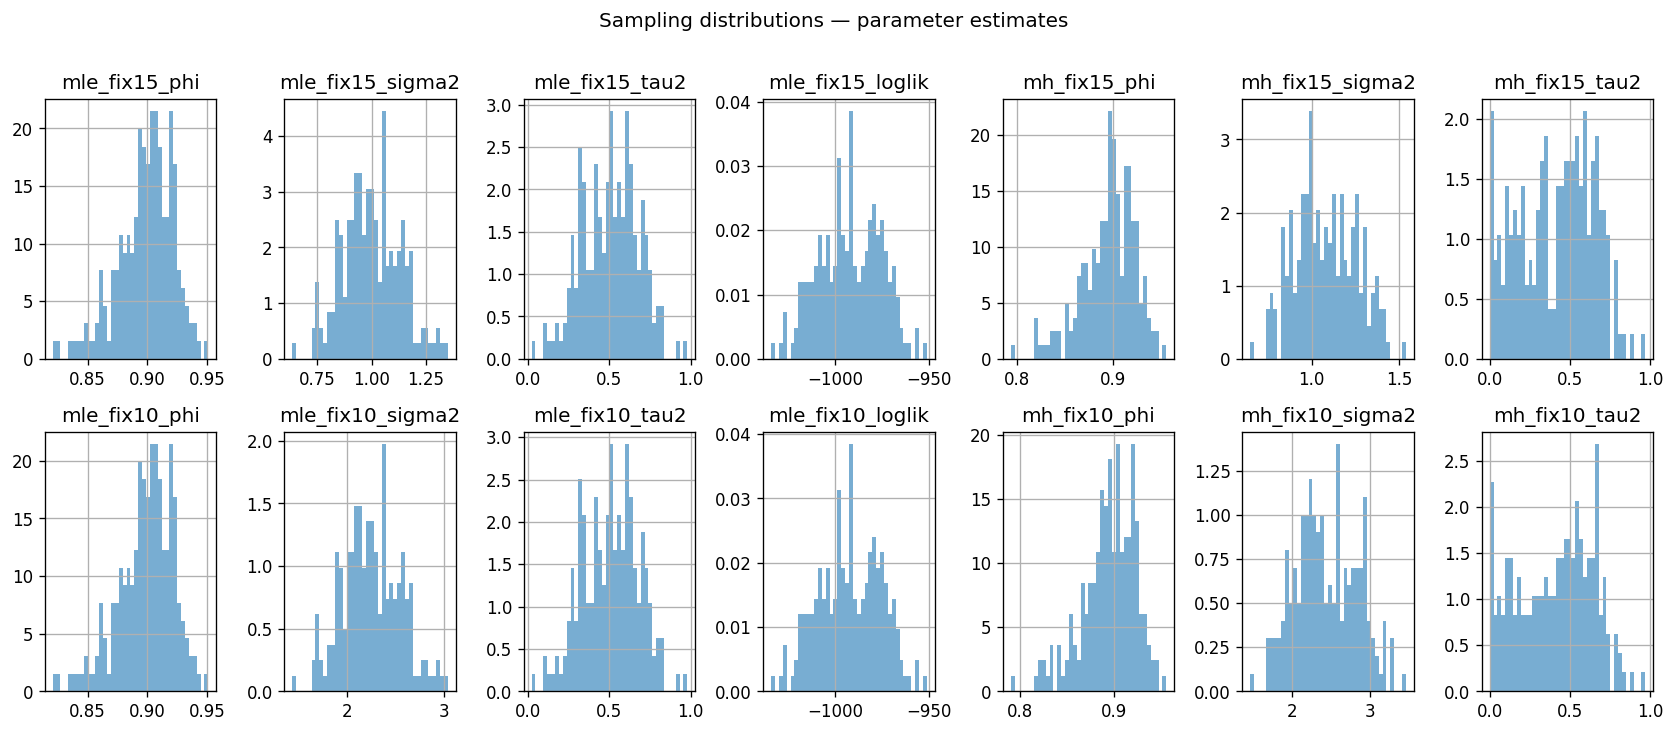

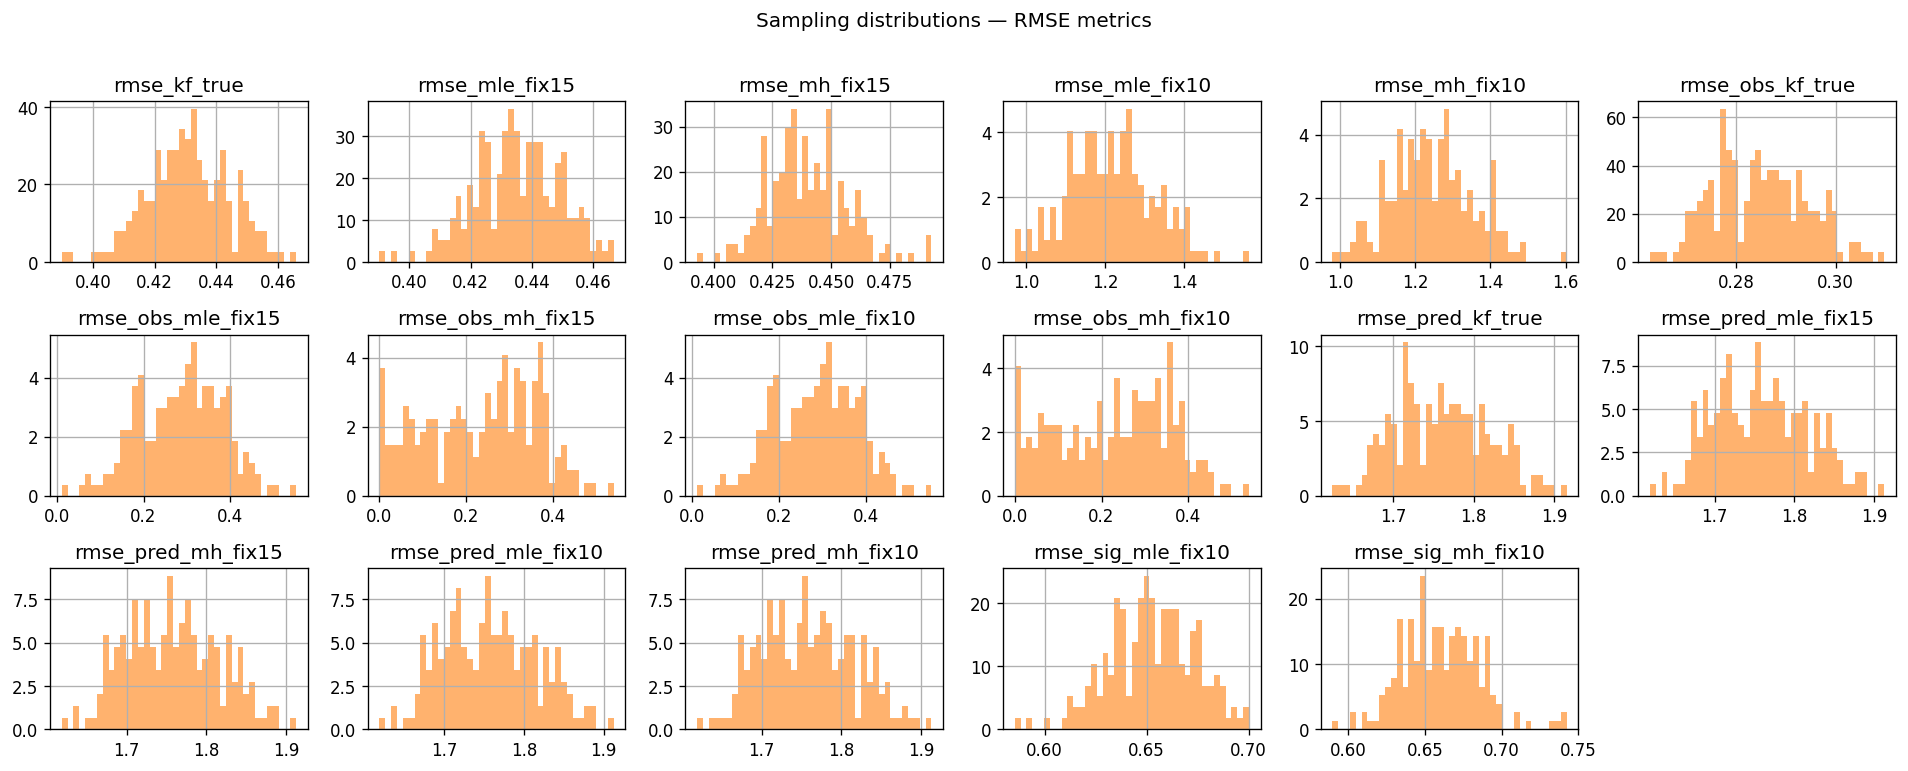

In [32]:
PARAM_COLS = [c for c in results_df.columns if not c.startswith('rmse')]
RMSE_COLS  = [c for c in results_df.columns if c.startswith('rmse')]

fig = results_df[PARAM_COLS].hist(bins=40, figsize=(14, 6),
                                   color='tab:blue', alpha=0.6, density=True, layout=(2, 7))
plt.suptitle('Sampling distributions — parameter estimates', y=1.01)
plt.tight_layout(); plt.show()

fig = results_df[RMSE_COLS].hist(bins=40, figsize=(16, 8),
                                  color='tab:orange', alpha=0.6, density=True, layout=(4, 6))
plt.suptitle('Sampling distributions — RMSE metrics', y=1.01)
plt.tight_layout(); plt.show()


## 8. Filtering using estimated parameters

## 9. RMSE analysis

We compare the estimated latent state $\hat{x}_t$ with the true simulated latent state $x_t$. Since this is synthetic data, the true state is known.

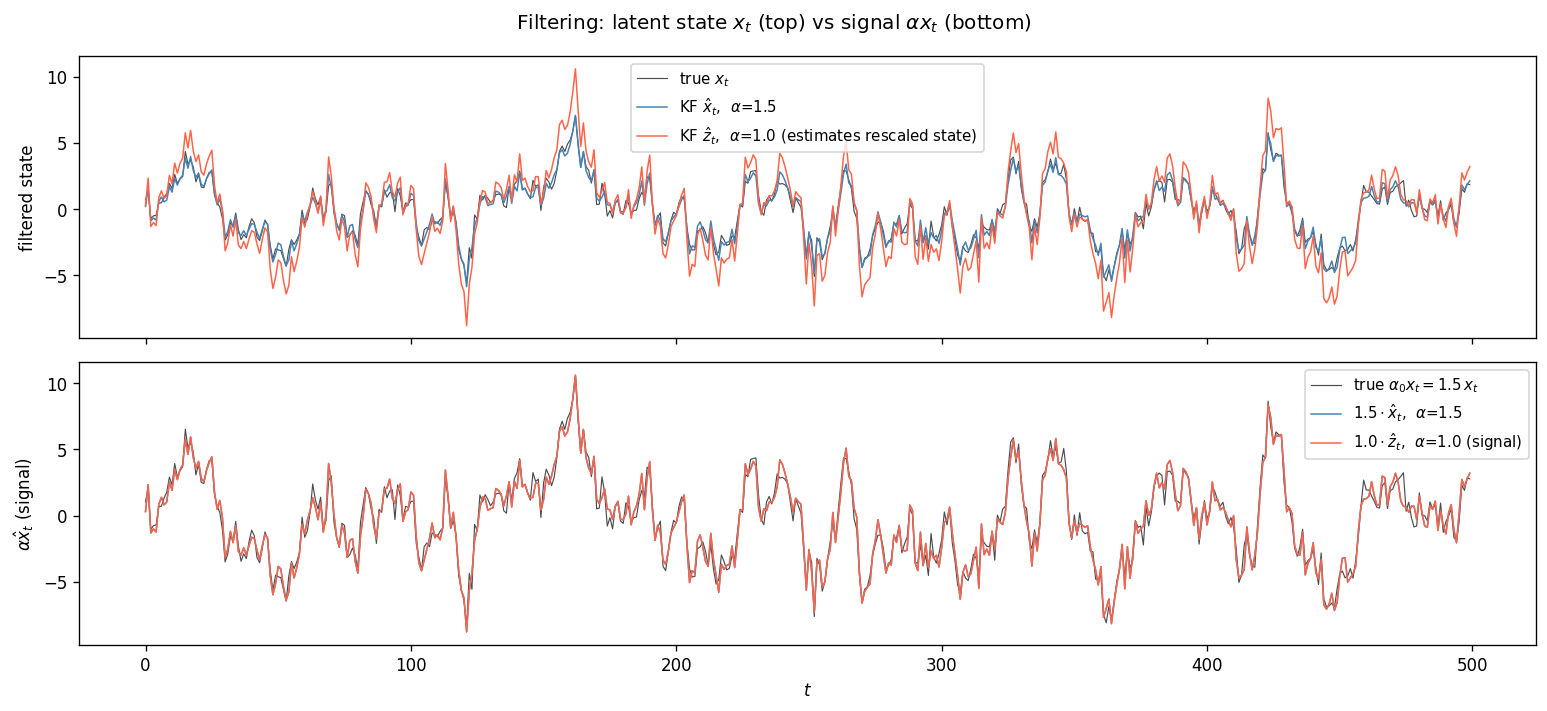

x-space RMSE:      fix15=0.3984   fix10=1.1643
signal-space RMSE: fix15=0.5976   fix10=0.5976


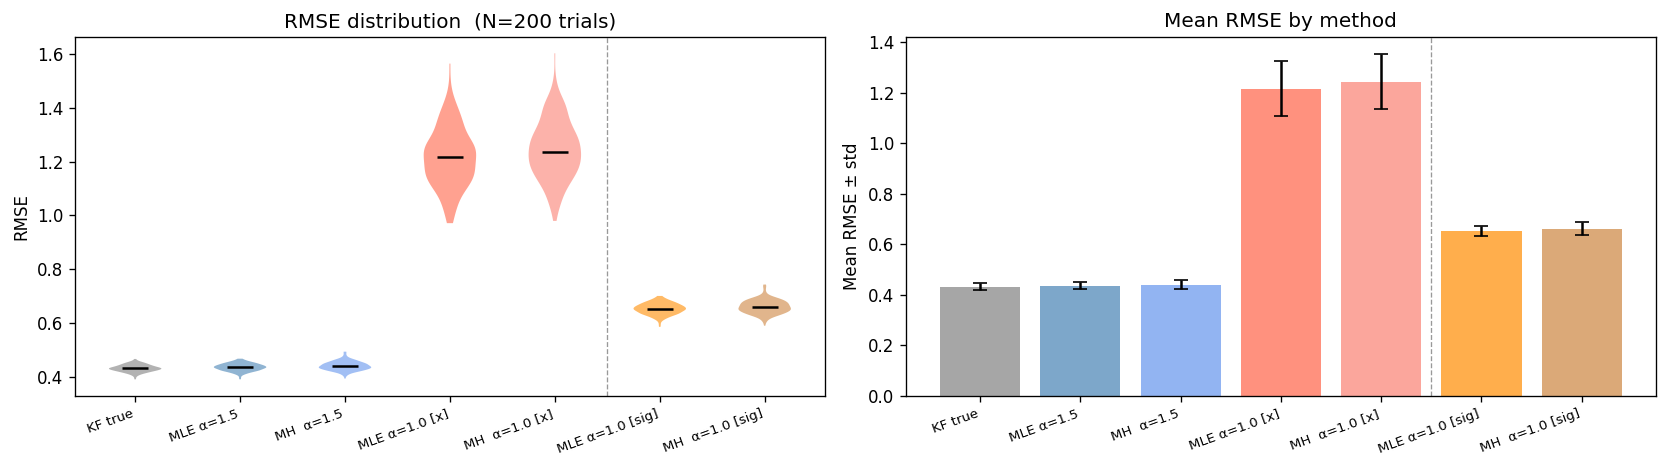


Method                      Mean       Std    Median  Space
----------------------------------------------------------
KF true                   0.4310    0.0133    0.4309  [x]
MLE α=1.5                 0.4350    0.0140    0.4345  [x]
MH  α=1.5                 0.4399    0.0169    0.4387  [x]
MLE α=1.0 [x]             1.2148    0.1087    1.2152  [x]
MH  α=1.0 [x]             1.2435    0.1089    1.2354  [x]
MLE α=1.0 [sig]           0.6525    0.0210    0.6518  [sig]
MH  α=1.0 [sig]           0.6602    0.0254    0.6588  [sig]


In [33]:
# ── Single-trial illustration: x_t and alpha*x_t under different alpha assumptions ──────
def run_kf_means(phi, alpha, sigma2, tau2, obs):
    m = LinearGaussianSSM(a=np.array([[phi]]), c=np.array([[alpha]]),
                          q=np.array([[sigma2]]), r=np.array([[tau2]]))
    means, _, _ = KalmanFilter(m, obs).run_filter()
    return means.ravel()

kf_demo_fix15 = run_kf_means(mle_fix15['phi'], 1.5, mle_fix15['sigma2'], mle_fix15['tau2'], observations)
kf_demo_fix10 = run_kf_means(mle_fix10['phi'], 1.0, mle_fix10['sigma2'], mle_fix10['tau2'], observations)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig.suptitle(r'Filtering: latent state $x_t$ (top) vs signal $\alpha x_t$ (bottom)')

axes[0].plot(states.ravel(), lw=0.7, color='black', alpha=0.7, label=r'true $x_t$')
axes[0].plot(kf_demo_fix15,  lw=0.9, color='steelblue', label=r'KF $\hat{x}_t$,  $\alpha$=1.5')
axes[0].plot(kf_demo_fix10,  lw=0.9, color='tomato',    label=r'KF $\hat{z}_t$,  $\alpha$=1.0 (estimates rescaled state)')
axes[0].set_ylabel('filtered state'); axes[0].legend(fontsize=9)

axes[1].plot(alpha_true * states.ravel(), lw=0.7, color='black', alpha=0.7, label=r'true $\alpha_0 x_t = 1.5\,x_t$')
axes[1].plot(1.5 * kf_demo_fix15,         lw=0.9, color='steelblue', label=r'$1.5\cdot\hat{x}_t$,  $\alpha$=1.5')
axes[1].plot(1.0 * kf_demo_fix10,         lw=0.9, color='tomato',    label=r'$1.0\cdot\hat{z}_t$,  $\alpha$=1.0 (signal)')
axes[1].set_ylabel(r'$\alpha\hat{x}_t$ (signal)'); axes[1].set_xlabel('$t$'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"x-space RMSE:      fix15={rmse(states.ravel(), kf_demo_fix15):.4f}   fix10={rmse(states.ravel(), kf_demo_fix10):.4f}")
print(f"signal-space RMSE: fix15={rmse(alpha_true*states.ravel(), 1.5*kf_demo_fix15):.4f}   fix10={rmse(alpha_true*states.ravel(), 1.0*kf_demo_fix10):.4f}")

# ── Multi-trial RMSE distributions ───────────────────────────────────────────
# For correctly-specified methods, signal RMSE = alpha_true * x-RMSE (simple rescaling)
results_df['rmse_sig_kf_true']   = alpha_true * results_df['rmse_kf_true']
results_df['rmse_sig_mle_fix15'] = alpha_true * results_df['rmse_mle_fix15']
results_df['rmse_sig_mh_fix15']  = alpha_true * results_df['rmse_mh_fix15']

rmse_specs = [
    ('rmse_kf_true',       'KF true',          'grey',          'x'),
    ('rmse_mle_fix15',     'MLE α=1.5',        'steelblue',     'x'),
    ('rmse_mh_fix15',      'MH  α=1.5',        'cornflowerblue','x'),
    ('rmse_mle_fix10',     'MLE α=1.0 [x]',   'tomato',        'x'),
    ('rmse_mh_fix10',      'MH  α=1.0 [x]',   'salmon',        'x'),
    ('rmse_sig_mle_fix10', 'MLE α=1.0 [sig]', 'darkorange',    'sig'),
    ('rmse_sig_mh_fix10',  'MH  α=1.0 [sig]', 'peru',          'sig'),
]
cols_r, labels_r, colors_r = [c for c,*_ in rmse_specs], [l for _,l,*_ in rmse_specs], [k for _,_,k,_ in rmse_specs]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
vp = ax.violinplot([results_df[c].values for c in cols_r], showmedians=True, showextrema=False)
for body, col in zip(vp['bodies'], colors_r):
    body.set_facecolor(col); body.set_alpha(0.6)
vp['cmedians'].set_color('black')
ax.set_xticks(range(1, len(cols_r) + 1))
ax.set_xticklabels(labels_r, rotation=20, ha='right', fontsize=8)
ax.axvline(5.5, color='black', lw=0.8, ls='--', alpha=0.4)   # x-space | signal-space divider
ax.set_ylabel('RMSE'); ax.set_title(f'RMSE distribution  (N={N_TRIALS} trials)')

ax = axes[1]
means_r = [results_df[c].mean() for c in cols_r]
stds_r  = [results_df[c].std()  for c in cols_r]
ax.bar(range(len(cols_r)), means_r, yerr=stds_r, capsize=4, color=colors_r, alpha=0.7)
ax.set_xticks(range(len(cols_r)))
ax.set_xticklabels(labels_r, rotation=20, ha='right', fontsize=8)
ax.axvline(4.5, color='black', lw=0.8, ls='--', alpha=0.4)
ax.set_ylabel('Mean RMSE ± std'); ax.set_title('Mean RMSE by method')
plt.tight_layout(); plt.show()

print(f"\n{'Method':<22}  {'Mean':>8}  {'Std':>8}  {'Median':>8}  Space")
print('-' * 58)
for col, lbl, _, space in rmse_specs:
    v = results_df[col]
    print(f"{lbl:<22}  {v.mean():>8.4f}  {v.std():>8.4f}  {v.median():>8.4f}  [{space}]")

## 10. Hypothesis tests on parameter estimates

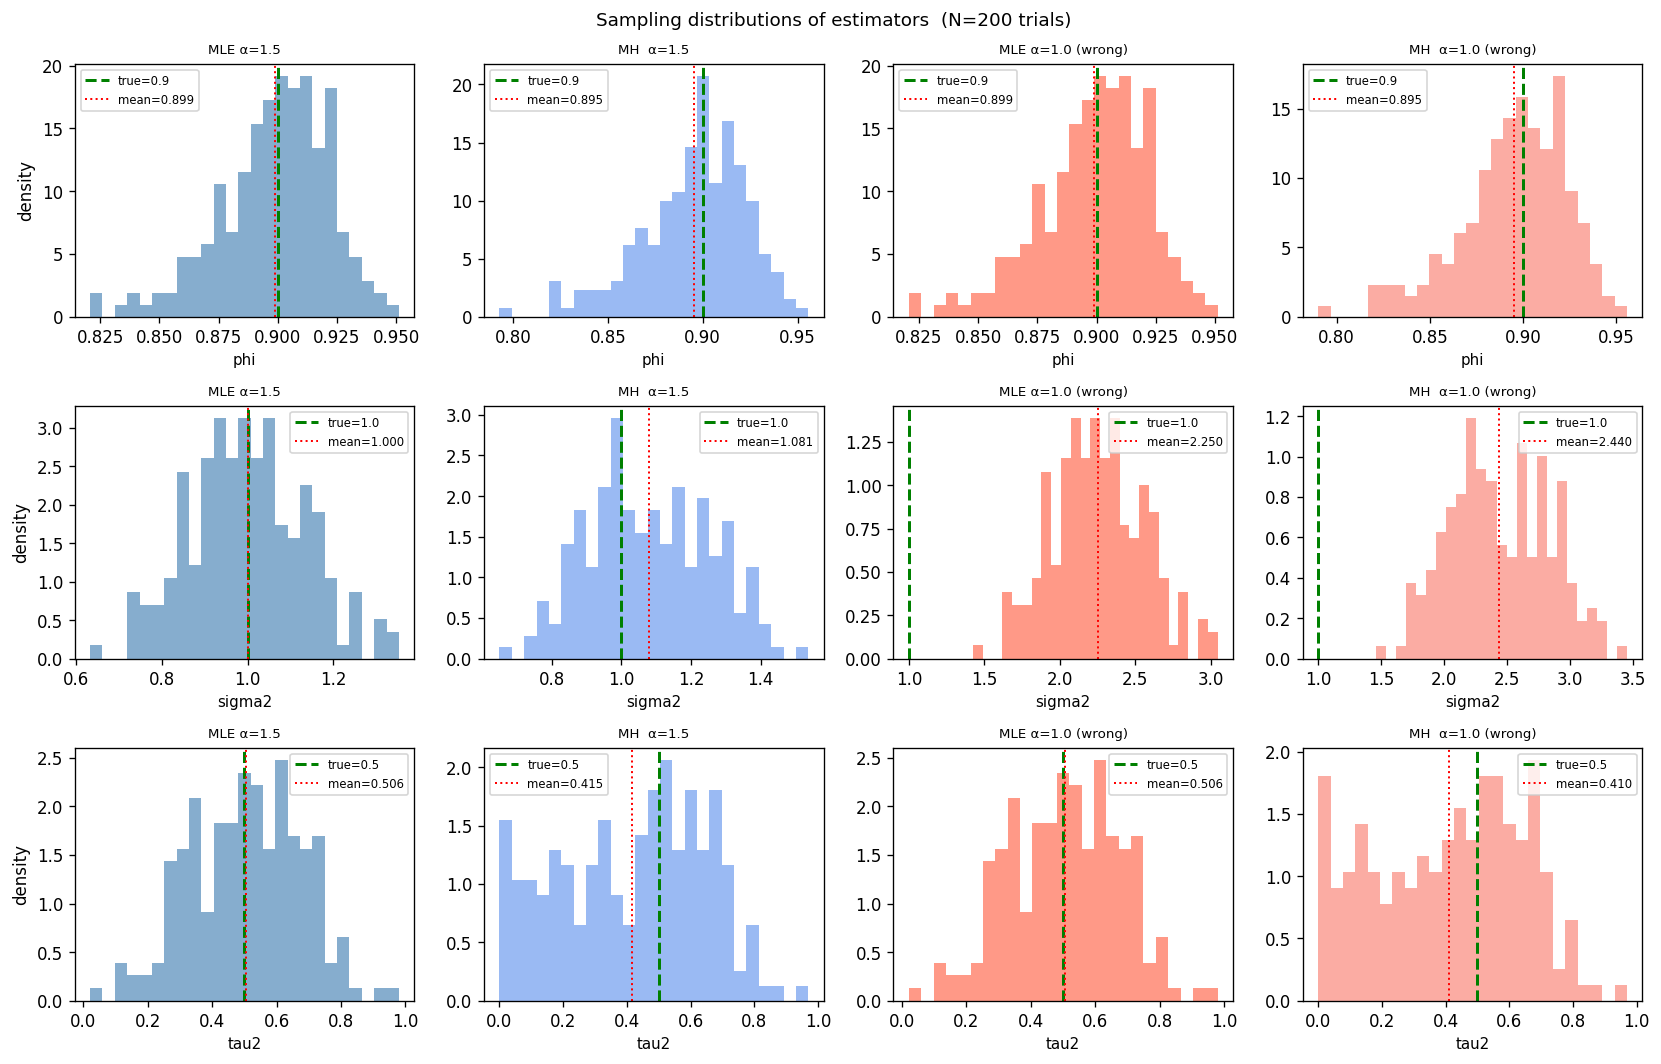

H₀: E[estimator] = true value   (reject at α=0.05)

Method                  Param       True      Mean      Bias       Std        t           p   *
--------------------------------------------------------------------------------------------
MLE α=1.5               phi         0.90    0.8987   -0.0013    0.0231    -0.78  4.3595e-01    
MLE α=1.5               sigma2      1.00    1.0000    0.0000    0.1333     0.00  9.9750e-01    
MLE α=1.5               tau2        0.50    0.5059    0.0059    0.1712     0.48  6.3008e-01    

MH  α=1.5               phi         0.90    0.8953   -0.0047    0.0278    -2.36  1.9435e-02   *
MH  α=1.5               sigma2      1.00    1.0807    0.0807    0.1744     6.52  5.5305e-10   *
MH  α=1.5               tau2        0.50    0.4148   -0.0852    0.2292    -5.24  4.0094e-07   *

MLE α=1.0 (wrong)       phi         0.90    0.8987   -0.0013    0.0231    -0.78  4.3594e-01    
MLE α=1.0 (wrong)       sigma2      1.00    2.2501    1.2501    0.2999    58.81  9.19

In [34]:
from scipy.stats import ttest_1samp

TRUE_P = {'phi': phi_true, 'sigma2': sigma2_true, 'tau2': tau2_true}
est_methods = [
    ('mle_fix15', 'MLE α=1.5',         'steelblue'),
    ('mh_fix15',  'MH  α=1.5',         'cornflowerblue'),
    ('mle_fix10', 'MLE α=1.0 (wrong)', 'tomato'),
    ('mh_fix10',  'MH  α=1.0 (wrong)', 'salmon'),
]

# Sampling distribution plots: rows = params, cols = methods
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle(f'Sampling distributions of estimators  (N={N_TRIALS} trials)', fontsize=11)
for row_i, param in enumerate(['phi', 'sigma2', 'tau2']):
    tv = TRUE_P[param]
    for col_i, (mk, mname, col) in enumerate(est_methods):
        ax = axes[row_i, col_i]
        vals = results_df[f'{mk}_{param}'].values
        ax.hist(vals, bins=25, density=True, color=col, alpha=0.65, edgecolor='none')
        ax.axvline(tv,          color='green', lw=1.8, ls='--', label=f'true={tv}')
        ax.axvline(vals.mean(), color='red',   lw=1.2, ls=':',  label=f'mean={vals.mean():.3f}')
        ax.set_xlabel(param, fontsize=9); ax.set_title(mname, fontsize=8)
        if col_i == 0:
            ax.set_ylabel('density')
        ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

# One-sample t-tests: H₀: E[estimate] = true value
print(f"H₀: E[estimator] = true value   (reject at α=0.05)\n")
print(f"{'Method':<22}  {'Param':<8}  {'True':>6}  {'Mean':>8}  {'Bias':>8}  {'Std':>8}  {'t':>7}  {'p':>10}  {'*':>2}")
print('-' * 92)
for mk, mname, _ in est_methods:
    for param, tv in TRUE_P.items():
        vals = results_df[f'{mk}_{param}'].values
        t, p = ttest_1samp(vals, tv)
        sig = '*' if p < 0.05 else ''
        print(f"{mname:<22}  {param:<8}  {tv:>6.2f}  {vals.mean():>8.4f}  "
              f"{vals.mean()-tv:>8.4f}  {vals.std():>8.4f}  {t:>7.2f}  {p:>10.4e}  {sig:>2}")
    print()

Based on the hypothesis test, the MH estimator is having a harder time than MLE of learning sigma2 and tau2, regardless of misspecification of alpha. This may be due to one of several factors, for example the length of the chain N_MH, bad proposal distribution, or other hyperparameter tuning.

## 11. $\sigma^2$ and $\tau^2$ estimates scatter plot



<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_19894/3325084865.py:50: SyntaxWarning: invalid escape sequence '\s'
  f'  (N={N_TRIALS} trials,  ellipses = 2$\sigma$ contours)',


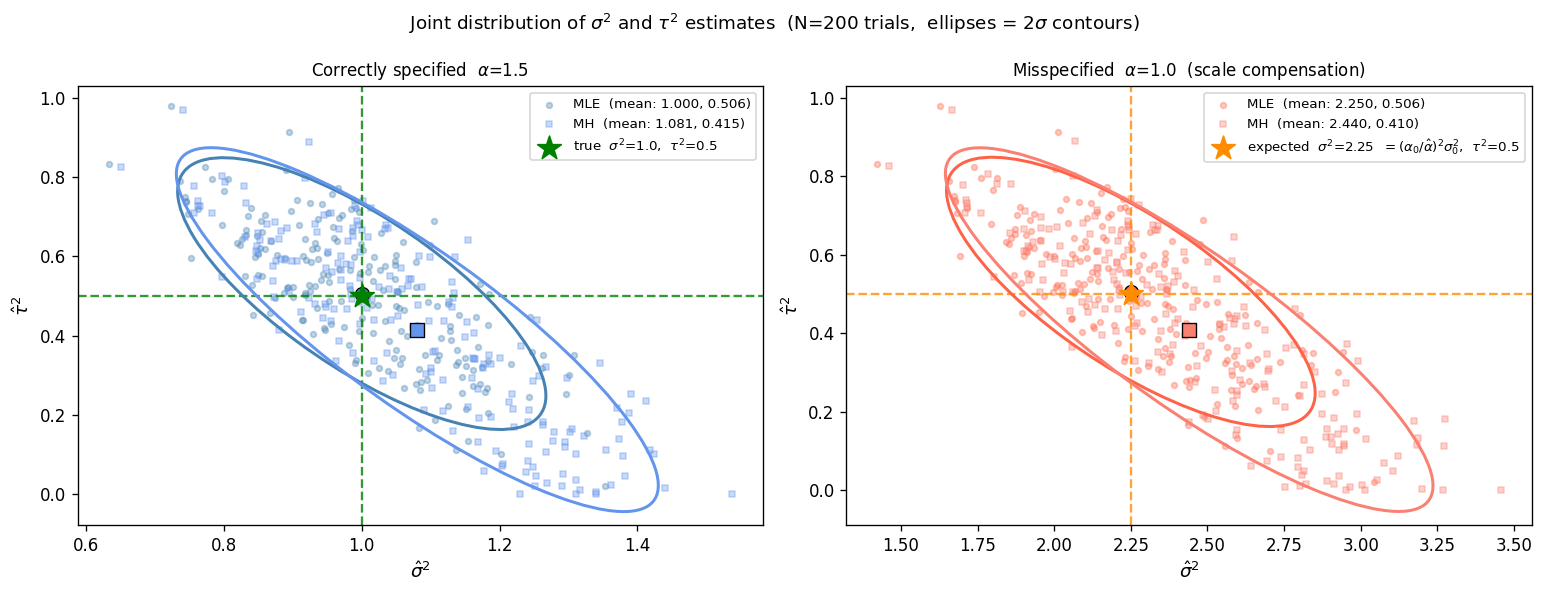


Method              s2 mean    s2 std    t2 mean    t2 std    corr(s2,t2)
------------------------------------------------------------------------
MLE a=1.5            1.0000    0.1333     0.5059    0.1712        -0.7520
  ref:              1.0000              0.5000
MH  a=1.5            1.0807    0.1744     0.4148    0.2292        -0.8561
  ref:              1.0000              0.5000
MLE a=1.0            2.2501    0.2999     0.5059    0.1712        -0.7520
  ref:              2.2500              0.5000
MH  a=1.0            2.4404    0.3966     0.4097    0.2312        -0.8588
  ref:              2.2500              0.5000


In [37]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def _cov_ellipse(x, y, ax, n_std=2.0, **kw):
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell = Ellipse((0, 0), width=2*np.sqrt(1 + pearson), height=2*np.sqrt(1 - pearson), **kw)
    sx = np.sqrt(cov[0, 0]) * n_std
    sy = np.sqrt(cov[1, 1]) * n_std
    tfm = (transforms.Affine2D()
           .rotate_deg(45)
           .scale(sx, sy)
           .translate(np.mean(x), np.mean(y)))
    ell.set_transform(tfm + ax.transData)
    return ax.add_patch(ell)

# expected sigma2 when alpha=1.0: inflates by (alpha_true / alpha_fix)^2
expected_sigma2_fix10 = (alpha_true / ALPHA_FIX10)**2 * sigma2_true   # = 2.25

method_groups = [
    {
        'title':   r'Correctly specified  $\alpha$=1.5',
        'methods': [
            ('mle_fix15', 'MLE', 'steelblue',      'o'),
            ('mh_fix15',  'MH',  'cornflowerblue',  's'),
        ],
        'ref_s2':  sigma2_true,
        'ref_t2':  tau2_true,
        'ref_lbl': rf'true  $\sigma^2$={sigma2_true},  $\tau^2$={tau2_true}',
        'ref_col': 'green',
    },
    {
        'title':   r'Misspecified  $\alpha$=1.0  (scale compensation)',
        'methods': [
            ('mle_fix10', 'MLE', 'tomato', 'o'),
            ('mh_fix10',  'MH',  'salmon',  's'),
        ],
        'ref_s2':  expected_sigma2_fix10,
        'ref_t2':  tau2_true,
        'ref_lbl': (rf'expected  $\sigma^2$={expected_sigma2_fix10:.2f}'
                    rf'  $= (\alpha_0/\hat{{\alpha}})^2 \sigma_0^2$,'
                    rf'  $\tau^2$={tau2_true}'),
        'ref_col': 'darkorange',
    },
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    r'Joint distribution of $\sigma^2$ and $\tau^2$ estimates'
    f'  (N={N_TRIALS} trials,  ellipses = 2$\sigma$ contours)',
    fontsize=11,
)

for ax, grp in zip(axes, method_groups):
    for mk, lbl, col, marker in grp['methods']:
        s2 = results_df[f'{mk}_sigma2'].values
        t2 = results_df[f'{mk}_tau2'].values
        ax.scatter(s2, t2, s=12, alpha=0.35, color=col, marker=marker,
                   label=f'{lbl}  (mean: {s2.mean():.3f}, {t2.mean():.3f})')
        _cov_ellipse(s2, t2, ax, n_std=2.0,
                     edgecolor=col, facecolor='none', lw=1.8, zorder=3)
        ax.scatter(s2.mean(), t2.mean(), s=70, color=col,
                   marker=marker, edgecolors='black', linewidths=0.8, zorder=4)

    ax.axvline(grp['ref_s2'], color=grp['ref_col'], lw=1.4, ls='--', alpha=0.8)
    ax.axhline(grp['ref_t2'], color=grp['ref_col'], lw=1.4, ls='--', alpha=0.8)
    ax.scatter([grp['ref_s2']], [grp['ref_t2']], marker='*', s=220,
               color=grp['ref_col'], zorder=5, label=grp['ref_lbl'])

    ax.set_xlabel(r'$\hat{\sigma}^2$', fontsize=11)
    ax.set_ylabel(r'$\hat{\tau}^2$', fontsize=11)
    ax.set_title(grp['title'], fontsize=10)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout(); plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Method':<16}  {'s2 mean':>9}  {'s2 std':>8}  {'t2 mean':>9}  {'t2 std':>8}  {'corr(s2,t2)':>13}")
print('-' * 72)
for lbl, mk, ref_s2, ref_t2 in [
    ('MLE a=1.5', 'mle_fix15', sigma2_true,           tau2_true),
    ('MH  a=1.5', 'mh_fix15',  sigma2_true,           tau2_true),
    ('MLE a=1.0', 'mle_fix10', expected_sigma2_fix10, tau2_true),
    ('MH  a=1.0', 'mh_fix10',  expected_sigma2_fix10, tau2_true),
]:
    s2 = results_df[f'{mk}_sigma2'].values
    t2 = results_df[f'{mk}_tau2'].values
    corr = np.corrcoef(s2, t2)[0, 1]
    print(f"{lbl:<16}  {s2.mean():>9.4f}  {s2.std():>8.4f}  "
          f"{t2.mean():>9.4f}  {t2.std():>8.4f}  {corr:>13.4f}")
    print(f"  ref:           {ref_s2:>9.4f}           {ref_t2:>9.4f}")


Choice of alpha did not significantly affect the correlation between sigma2 and tau2. Correlation  between sigma2 and tau2 is more negative for MH than ME. The bias in the MH estimates may be due to the choice of prior and proposal distributions. May require further investigation.

## 12. Hypothesis tests on RMSE values

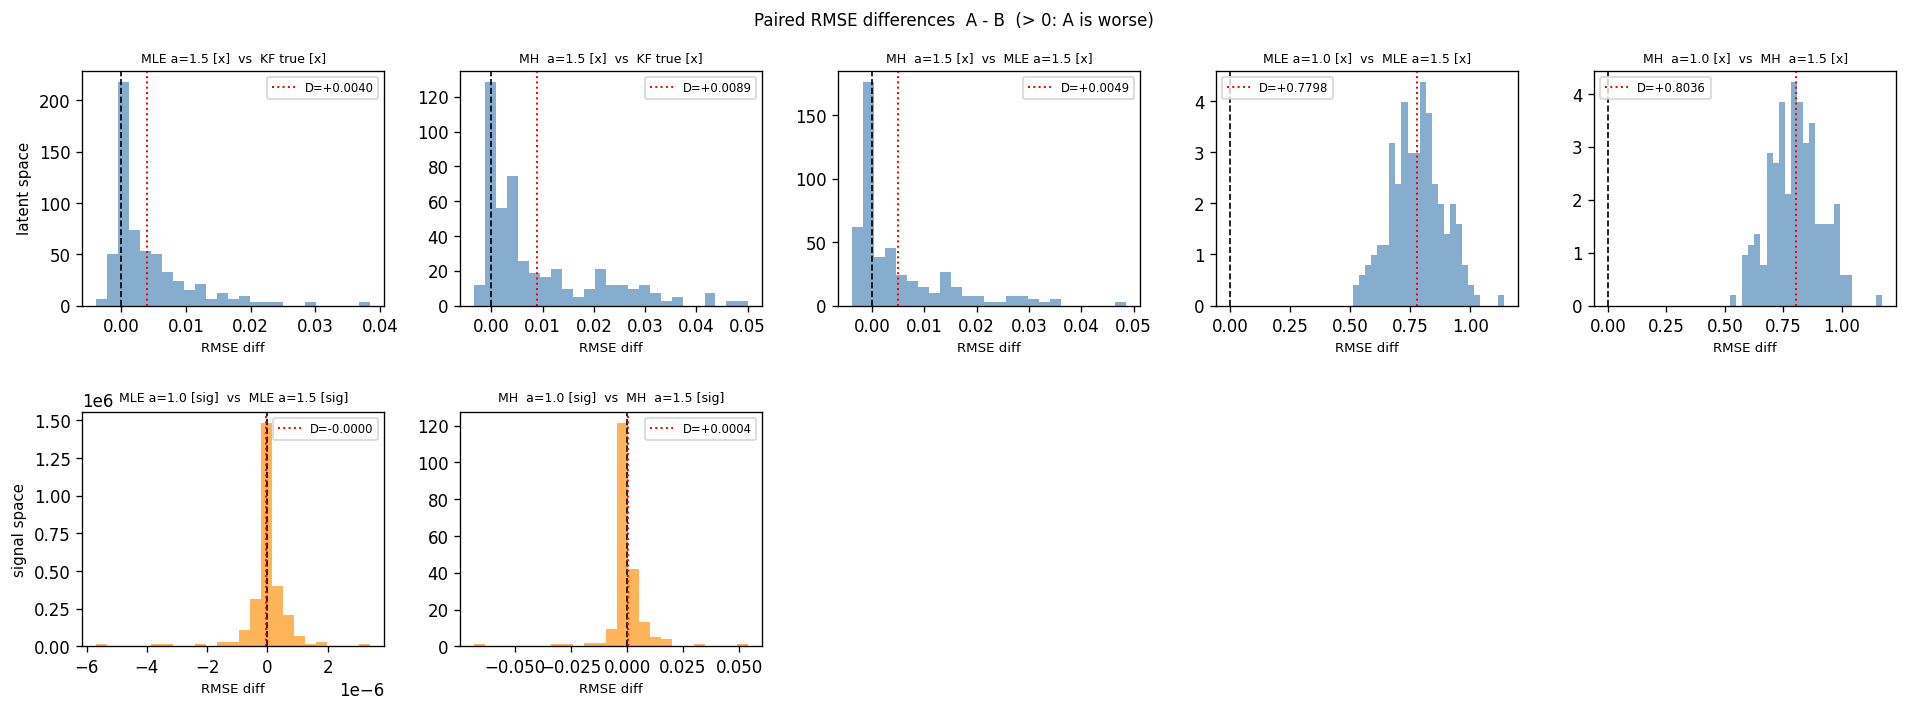


-- Latent x-space  rmse(x_hat, x_t) --
H0: E[RMSE(A)] = E[RMSE(B)],  paired t-test  (a=0.05)

Comparison                                   Mean(A)   Mean(B)    D mean        t           p   *
----------------------------------------------------------------------------------------------------
MLE a=1.5 [x]  vs  KF true [x]                0.4350    0.4310   +0.0040     9.41  1.2729e-17   *
MH  a=1.5 [x]  vs  KF true [x]                0.4399    0.4310   +0.0089    11.12  1.1518e-22   *
MH  a=1.5 [x]  vs  MLE a=1.5 [x]              0.4399    0.4350   +0.0049     7.50  2.0981e-12   *
MLE a=1.0 [x]  vs  MLE a=1.5 [x]              1.2148    0.4350   +0.7798   100.65  1.2241e-172   *
MH  a=1.0 [x]  vs  MH  a=1.5 [x]              1.2435    0.4399   +0.8036   104.95  3.4803e-176   *

-- Signal space    rmse(a_est * x_hat, a_true * x_t) --
H0: E[RMSE(A)] = E[RMSE(B)],  paired t-test  (a=0.05)

Comparison                                   Mean(A)   Mean(B)    D mean        t           p   *
----

In [38]:
from scipy.stats import ttest_rel

ALPHA_LEVEL = 0.05

# rmse_sig_kf_true / rmse_sig_mle_fix15 / rmse_sig_mh_fix15 are signal-space
# versions of the correctly-specified baselines (= alpha_true * latent RMSE),
# created in the RMSE analysis cell above.

# ── latent x-space: rmse(x̂_{t|t}, x_t) ─────────────────────────────────────
latent_comps = [
    ('rmse_mle_fix15', 'rmse_kf_true',   'MLE a=1.5 [x]  vs  KF true [x]'),
    ('rmse_mh_fix15',  'rmse_kf_true',   'MH  a=1.5 [x]  vs  KF true [x]'),
    ('rmse_mh_fix15',  'rmse_mle_fix15', 'MH  a=1.5 [x]  vs  MLE a=1.5 [x]'),
    ('rmse_mle_fix10', 'rmse_mle_fix15', 'MLE a=1.0 [x]  vs  MLE a=1.5 [x]'),
    ('rmse_mh_fix10',  'rmse_mh_fix15',  'MH  a=1.0 [x]  vs  MH  a=1.5 [x]'),
]

# ── signal space: rmse(a_est * x̂_{t|t}, a_true * x_t) ──────────────────────
signal_comps = [
    ('rmse_sig_mle_fix10', 'rmse_sig_mle_fix15', 'MLE a=1.0 [sig]  vs  MLE a=1.5 [sig]'),
    ('rmse_sig_mh_fix10',  'rmse_sig_mh_fix15',  'MH  a=1.0 [sig]  vs  MH  a=1.5 [sig]'),
]

n_cols = max(len(latent_comps), len(signal_comps))

# ── paired difference histograms ──────────────────────────────────────────────
fig, axes = plt.subplots(2, n_cols, figsize=(16, 6))
fig.suptitle('Paired RMSE differences  A - B  (> 0: A is worse)', fontsize=10)

for row, (group, color) in enumerate(
        [(latent_comps, 'steelblue'), (signal_comps, 'darkorange')]):
    for col, (col_a, col_b, name) in enumerate(group):
        ax = axes[row, col]
        diff = results_df[col_a].values - results_df[col_b].values
        ax.hist(diff, bins=25, density=True, color=color, alpha=0.65, edgecolor='none')
        ax.axvline(0,           color='black', lw=1.0, ls='--')
        ax.axvline(diff.mean(), color='red',   lw=1.2, ls=':', label=f'D={diff.mean():+.4f}')
        ax.set_title(name, fontsize=7.5)
        ax.set_xlabel('RMSE diff', fontsize=8)
        ax.legend(fontsize=7)
    for col in range(len(group), n_cols):
        axes[row, col].set_visible(False)

axes[0, 0].set_ylabel('latent space', fontsize=9)
axes[1, 0].set_ylabel('signal space', fontsize=9)
plt.tight_layout(); plt.show()

# ── paired t-tests ────────────────────────────────────────────────────────────
def _print_tests(comps, header):
    print(f'\n{header}')
    print(f'H0: E[RMSE(A)] = E[RMSE(B)],  paired t-test  (a={ALPHA_LEVEL})\n')
    print(f"{'Comparison':<42}  {'Mean(A)':>8}  {'Mean(B)':>8}  "
          f"{'D mean':>8}  {'t':>7}  {'p':>10}  {'*':>2}")
    print('-' * 100)
    for col_a, col_b, name in comps:
        a = results_df[col_a].values
        b = results_df[col_b].values
        t, p = ttest_rel(a, b)
        sig = '*' if p < ALPHA_LEVEL else ''
        print(f"{name:<42}  {a.mean():>8.4f}  {b.mean():>8.4f}  "
              f"{(a-b).mean():>+8.4f}  {t:>7.2f}  {p:>10.4e}  {sig:>2}")

_print_tests(latent_comps, '-- Latent x-space  rmse(x_hat, x_t) --')
_print_tests(signal_comps, '-- Signal space    rmse(a_est * x_hat, a_true * x_t) --')


## 13. Summary

### Filtering performance (Section 3)



### Parameter estimation — free $\alpha$ (Sections 4–5)



### Parameter estimation — fixed $\alpha$ (Section 7)



### Filtering under estimated parameters (Sections 8–9)


### Hypothesis tests (Sections 10–11)

**Parameter recovery (Section 10).** 

**RMSE tests (Section 11).** 

### Overall conclusion
